ddi_project_overview_fixed.svg

# Graphsage
graphsage_overview_nontechnical.svg

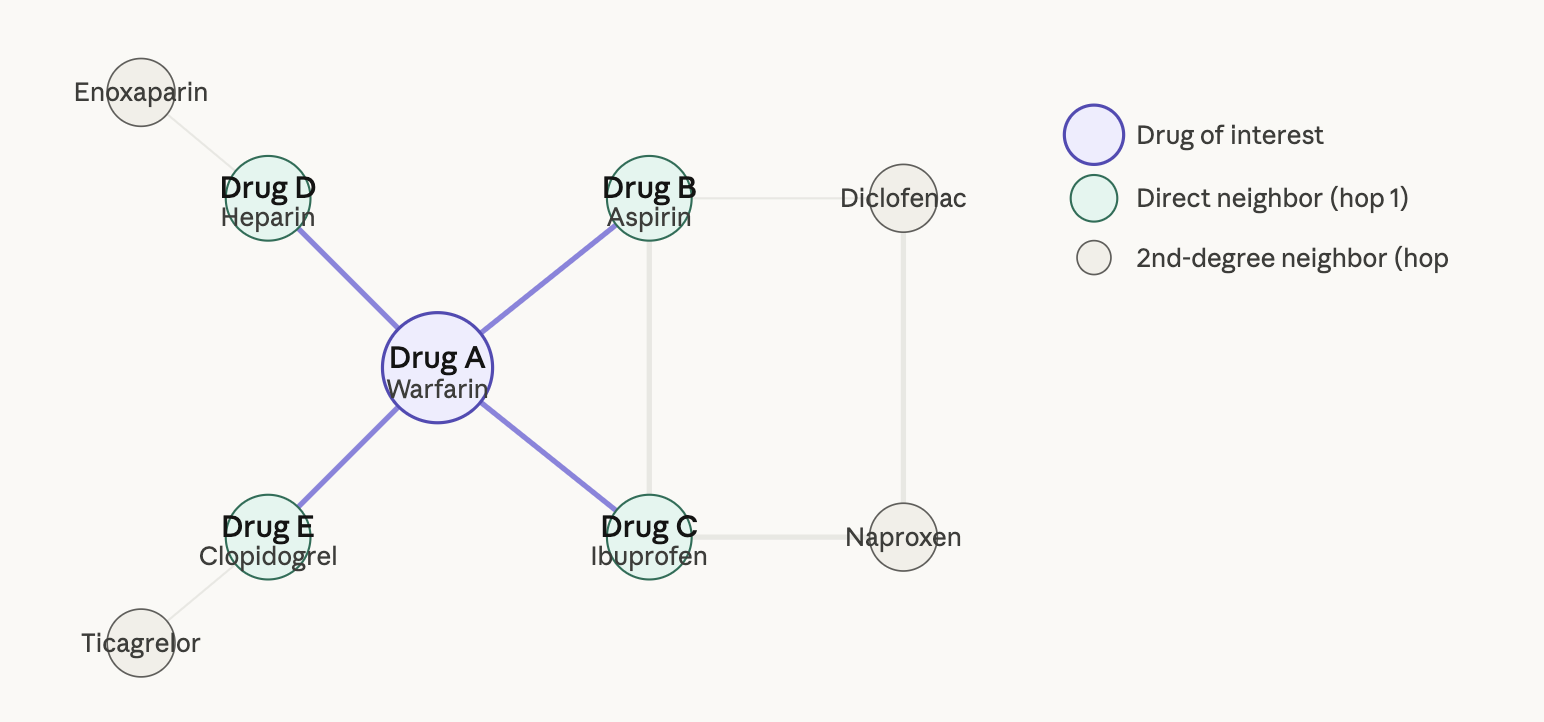

<h1>GraphSAGE for Explainable Drug-Drug Interaction Prediction</h1>

<hr>

<h2>Why GraphSAGE?</h2>

<p>We selected <strong>GraphSAGE</strong> (Graph SAmple and aggrEgatE, Hamilton et al. 2017) as our primary GNN architecture for three reasons. First, it learns a <strong>generalizable aggregation function</strong> rather than fixed spectral filters like GCN — meaning it can, in principle, generalize to unseen drugs without retraining. Second, it was designed for <strong>large-scale graphs</strong> with mini-batch training via neighborhood sampling, making it practical for OGB-DDI's 1.3M interactions. Third, Abbas et al. (2025) showed GraphSAGE achieved the <strong>highest accuracy (0.981) on OGB-DDI</strong> among all tested GNN architectures (GCN, GAT, AGDN).</p>

<hr>

<h2>How GraphSAGE Works</h2>

<p>GraphSAGE computes node representations through iterative <strong>neighborhood aggregation</strong>. At each layer, a drug's embedding is updated by:</p>

<ol>
  <li><strong>Gathering</strong> its neighbors' current embeddings from the interaction graph</li>
  <li><strong>Aggregating</strong> them using a learned function (we use mean aggregation)</li>
  <li><strong>Combining</strong> the aggregated neighborhood with the node's own embedding through a linear transformation + nonlinearity</li>
</ol>

<p>After <em>K</em> layers (we use 3), each drug's final embedding encodes information from its <strong>3-hop neighborhood</strong> — capturing not just direct interaction partners, but partners-of-partners.</p>

<p><strong>Update rule at each layer:</strong></p>

$$h_v^{(k)} = \sigma\!\left(W^{(k)} \cdot \text{CONCAT}\!\left(h_v^{(k-1)},\ \text{MEAN}\!\left(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)\right)\right)$$

<p>where $\mathcal{N}(v)$ are the neighbors of drug $v$, $W^{(k)}$ is a learned weight matrix at layer $k$, and $\sigma$ is the ReLU activation.</p>

<p>After 3 layers, each drug's embedding encodes its own identity plus aggregated information from its 3-hop neighborhood. Drugs with similar neighborhoods end up with similar embeddings → the link predictor scores them as likely to interact.</p>

<hr>

<h2>Two Variants: What Information Drives DDI Prediction?</h2>

<p>We train two GraphSAGE variants to isolate what information the model actually needs.</p>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th></th>
      <th>GraphSAGE — No Features</th>
      <th>GraphSAGE — With Features</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Initial embedding</strong></td>
      <td>Random vector (4,267 × 128)</td>
      <td>Linear projection of Morgan fingerprint (2,048 → 128)</td>
    </tr>
    <tr>
      <td><strong>What it encodes</strong></td>
      <td>Who interacts with whom</td>
      <td>Molecular structure + interaction network</td>
    </tr>
    <tr>
      <td><strong>Analogy</strong></td>
      <td>Word2Vec: context defines meaning</td>
      <td>Starts chemically informed, refined by network</td>
    </tr>
  </tbody>
</table>

<p>The only architectural difference is the first layer: <code>nn.Embedding</code> (random vectors) vs. <code>nn.Linear</code> (projects fingerprints). Any performance or explainability difference is attributable to molecular features.</p>

<hr>

<h2>Architecture Details</h2>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th>Component</th>
      <th>Configuration</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Encoder</strong></td>
      <td>3 × SAGEConv, hidden_dim = 128, mean aggregation, ReLU + Dropout (0.3)</td>
    </tr>
    <tr>
      <td><strong>Link predictor</strong></td>
      <td>3-layer MLP on Hadamard product of drug embeddings (symmetric by construction)</td>
    </tr>
    <tr>
      <td><strong>Training</strong></td>
      <td>BCE loss, 1:1 negative sampling, Adam (lr = 0.005), batch size 65,536</td>
    </tr>
    <tr>
      <td><strong>Evaluation</strong></td>
      <td>AUC-ROC, Hits@20, Precision, Recall, F1 — OGB official val/test splits</td>
    </tr>
  </tbody>
</table>

<blockquote style="border-left: 4px solid #ccc; padding-left: 12px; color: #555;">
<strong>Why batch size 65,536?</strong> GraphSAGE encodes the full graph at every step. With batch size 1,024 that means ~1,043 full-graph forward passes per epoch; with 65,536 it drops to ~17 — a ~60× reduction in redundant computation.
</blockquote>

<hr>

<h2>Evaluation Metrics</h2>

<p>The model outputs a raw logit per drug pair; sigmoid converts it to a probability. The 0.5 threshold is used for Precision, Recall, and F1. Primary metrics are <strong>threshold-independent</strong>:</p>

<ul>
  <li><strong>AUC-ROC</strong> — probability that the model ranks a real DDI above a random non-DDI. 0.5 = chance, 1.0 = perfect.</li>
  <li><strong>Hits@20</strong> (OGB official) — fraction of real DDIs whose score ranks in the top 20 among all negatives. Measures whether true interactions surface at the top of the ranked list — the critical region for clinical use.</li>
</ul>

<hr>

<h2>Explainability Methods</h2>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th>Method</th>
      <th>Variant</th>
      <th>What it explains</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Neighbor perturbation analysis</strong></td>
      <td>Both</td>
      <td>Removes one neighbor at a time; largest score drop = most influential drug</td>
    </tr>
    <tr>
      <td><strong>Integrated Gradients</strong></td>
      <td>With Features only</td>
      <td>Attributes each of the 2,048 fingerprint bits; top bits mapped to substructures via RDKit</td>
    </tr>
  </tbody>
</table>

<p>Together they answer: <em>which drugs matter?</em> (network relationships) and <em>which chemical features matter?</em> (molecular chemistry).</p>

<hr>

<h2>Biological Validation</h2>

<p>Fisher's exact test compares the model's <strong>top-5,000 highest-scoring test pairs</strong> against 5,000 random pairs. For each pair, we check whether both drugs share enzymes, targets, or transporters (DrugBank XML). A significant result (p &lt; 0.05) indicates the model is capturing real pharmacological mechanisms, not graph structure artifacts.</p>

<hr>

<h2>Drug Pairs Selected for Explainability Analysis</h2>

<p>Five pairs with known shared pharmacology were selected to validate model explanations against established mechanisms.</p>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th>Pair</th>
      <th>Shared CYP Enzymes</th>
      <th>Shared Targets</th>
      <th>Shared Transporters</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Terfenadine + Alprazolam</td>
      <td>CYP3A4, CYP3A5, CYP3A7</td>
      <td>—</td>
      <td>—</td>
    </tr>
    <tr>
      <td>Nilotinib + Dacomitinib</td>
      <td>CYP2C9, CYP2D6, CYP3A4</td>
      <td>—</td>
      <td>ABCB1, ABCG2</td>
    </tr>
    <tr>
      <td>Palonosetron + Clomipramine</td>
      <td>CYP1A2, CYP2D6, CYP3A4</td>
      <td>—</td>
      <td>—</td>
    </tr>
    <tr>
      <td>Flunitrazepam + Alprazolam</td>
      <td>CYP2C9, CYP3A4</td>
      <td>GABA(A) receptor, Translocator protein</td>
      <td>—</td>
    </tr>
    <tr>
      <td>Clomipramine + Atomoxetine</td>
      <td>CYP2C19, CYP2D6</td>
      <td>NET, SERT</td>
      <td>—</td>
    </tr>
  </tbody>
</table>

<p>These pairs cover three DDI mechanisms: <strong>metabolic competition</strong> (CYP enzymes), <strong>pharmacodynamic interaction</strong> (shared targets), and <strong>distribution interference</strong> (shared transporters). The same pairs are evaluated across MLP, GraphSAGE, and GAT for cross-model comparison.</p>

#Setting up

In [ ]:
import numpy as np

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive/ddi_capstone'):
    print(f)

molecular
drug_bank_parsing
GAT
MLP_baseline
graphsage


In [ ]:
for f in os.listdir('/content/drive/MyDrive/ddi_capstone/graphsage'):
    print(f)


best_graphsage_topo.pt
grapshage.ipynb


In [ ]:
!pip install torch-geometric ogb --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 10.4 MB/s eta 0:00:00


# Loading the dataset

In [ ]:
from torch.utils.data import DataLoader
from ogb.linkproppred import Evaluator

In [ ]:
import torch
import ogb.linkproppred.dataset_pyg as ogb_pyg
import os
import shutil

dataset_root_dir = 'dataset'
ogbl_ddi_processed_path = os.path.join(dataset_root_dir, 'ogbl_ddi', 'processed')

if os.path.exists(ogbl_ddi_processed_path):
    print(f"Deleting cached processed OGB-DDI data from: {os.path.abspath(ogbl_ddi_processed_path)}")
    shutil.rmtree(ogbl_ddi_processed_path)
    print("Deleted.")

# Patch torch.load safely
_original_load = torch.serialization.load
torch.load = lambda *args, **kwargs: _original_load(*args, **{**kwargs, 'weights_only': False})

dataset = ogb_pyg.PygLinkPropPredDataset(name='ogbl-ddi', root=dataset_root_dir)
data = dataset[0].to(device)
split_edge = dataset.get_edge_split()

# Restore
torch.load = _original_load

print(f"\nDataset: {dataset.name}")
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.edge_index.shape[1]}")
print(f"\nTrain edges: {split_edge['train']['edge'].shape}")
print(f"Val pos: {split_edge['valid']['edge'].shape}, Val neg: {split_edge['valid']['edge_neg'].shape}")
print(f"Test pos: {split_edge['test']['edge'].shape}, Test neg: {split_edge['test']['edge_neg'].shape}")

Deleting cached processed OGB-DDI data from: /content/dataset/ogbl_ddi/processed
Deleted.
Loading necessary files...
This might take a while.


Processing...


Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 32.51it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 2244.14it/s]

Saving...

Dataset: ogbl-ddi
Nodes: 4267
Edges: 2135822

Train edges: torch.Size([1067911, 2])
Val pos: torch.Size([133489, 2]), Val neg: torch.Size([101882, 2])
Test pos: torch.Size([133489, 2]), Test neg: torch.Size([95599, 2])



Done!


## Data preparation

In [ ]:
# ============================================
# Data Preparation
# ============================================
# OGB provides pre-defined train/val/test splits for fair benchmarking.
# Each split contains:
#   - Positive edges: known DDIs (drug pairs that DO interact)
#   - Negative edges (val/test only): drug pairs that do NOT interact
#     (used to evaluate if the model can distinguish real from fake interactions)
# Train split has no negatives — we generate them on-the-fly during training
# via random sampling (see training loop).


# Each tensor is shape (N, 2) where each row is [drug_a_idx, drug_b_idx].
train_pos = split_edge['train']['edge'].to(device)    # 1,067,911 known DDIs for training
val_pos   = split_edge['valid']['edge'].to(device)     # 133,489 DDIs held out for validation
val_neg   = split_edge['valid']['edge_neg'].to(device)  # 133,489 non-interactions for validation
test_pos  = split_edge['test']['edge'].to(device)       # 133,489 DDIs held out for final test
test_neg  = split_edge['test']['edge_neg'].to(device)   # 133,489 non-interactions for final test

# edge_index is the full graph structure in COO format: shape (2, num_edges).
# Row 0 = source nodes, Row 1 = target nodes.
# This is what GraphSAGE uses for message passing — it tells each drug
# who its neighbors are so it can aggregate their information.
edge_index = data.edge_index.to(device)

# DataLoader iterates over INDICES into train_pos, not the edges themselves.
# Each batch gives us a set of indices like [0, 42, 1337, ...], and we use
# those to look up the actual edges: train_pos[batch_idx] → [[drug_a, drug_b], ...]
# shuffle=True ensures different batches each epoch for better generalization.
train_loader = DataLoader(torch.arange(train_pos.shape[0]), batch_size=1024, shuffle=True)

# OGB's official evaluator computes Hits@20: "what fraction of true positives
# rank in the top 20 when scored against all negatives?"
# This is the standard metric for link prediction on OGB benchmarks.
evaluator = Evaluator(name='ogbl-ddi')

# Hyperparameters — kept identical to MLP and GraphSAGE for fair comparison.
# hidden_dim=128, num_layers=3 matches the config from Abbas et al. (2025).
# dropout=0.3 for regularization, patience=20 for early stopping.
config = {
    'hidden_dim': 128,     # Embedding dimension for all layers
    'num_layers': 3,       # 3 SAGEConv layers = 3-hop neighborhood aggregation
    'dropout': 0.3,        # Randomly zero 30% of neurons during training (prevents overfitting)
    'lr': 0.005,           # Adam learning rate
    'batch_size': 1024,    # Edges per batch (later increased to 65536 for efficiency)
    'num_epochs': 100,     # Maximum training epochs
    'patience': 20,        # Stop if validation AUC doesn't improve for 20 epochs
}

print("Data ready")
print(f"Config: {config}")
print(f"Train loader batches: {len(train_loader)}")

Data ready
Config: {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.005, 'batch_size': 1024, 'num_epochs': 100, 'patience': 20}
Train loader batches: 1043


## Architecture definition

In [ ]:
from IPython.display import HTML, display

display(HTML("""
<svg width="100%" viewBox="0 0 680 180" xmlns="http://www.w3.org/2000/svg">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="5" markerHeight="5" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>
<rect x="10" y="30" width="140" height="44" rx="6" fill="#E1F5EE" stroke="#0F6E56" stroke-width="0.8"/>
<text x="80" y="48" text-anchor="middle" font-size="11" font-weight="500" fill="#085041" font-family="sans-serif">nn.Embedding</text>
<text x="80" y="64" text-anchor="middle" font-size="10" fill="#0F6E56" font-family="sans-serif">4,267 × 128 (random)</text>
<rect x="10" y="104" width="140" height="44" rx="6" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.8"/>
<text x="80" y="122" text-anchor="middle" font-size="11" font-weight="500" fill="#633806" font-family="sans-serif">nn.Linear</text>
<text x="80" y="138" text-anchor="middle" font-size="10" fill="#854F0B" font-family="sans-serif">2,048 → 128 (fingerprint)</text>
<line x1="152" y1="52" x2="178" y2="52" stroke="#D85A30" stroke-width="0.8" stroke-dasharray="3 2"/>
<line x1="152" y1="126" x2="178" y2="126" stroke="#D85A30" stroke-width="0.8" stroke-dasharray="3 2"/>
<line x1="178" y1="52" x2="178" y2="126" stroke="#D85A30" stroke-width="0.8" stroke-dasharray="3 2"/>
<text x="184" y="93" font-size="10" fill="#993C1D" font-family="sans-serif">only difference</text>
<line x1="150" y1="52" x2="310" y2="89" stroke="#888780" stroke-width="0.8" marker-end="url(#arrow)"/>
<line x1="150" y1="126" x2="310" y2="91" stroke="#888780" stroke-width="0.8" marker-end="url(#arrow)"/>
<rect x="312" y="62" width="130" height="44" rx="6" fill="#EEEDFE" stroke="#534AB7" stroke-width="0.8"/>
<text x="377" y="80" text-anchor="middle" font-size="11" font-weight="500" fill="#3C3489" font-family="sans-serif">SAGEConv × 3</text>
<text x="377" y="96" text-anchor="middle" font-size="10" fill="#534AB7" font-family="sans-serif">hidden=128 · mean · ReLU</text>
<line x1="444" y1="84" x2="474" y2="84" stroke="#888780" stroke-width="0.8" marker-end="url(#arrow)"/>
<rect x="476" y="62" width="90" height="44" rx="6" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="0.8"/>
<text x="521" y="80" text-anchor="middle" font-size="11" font-weight="500" fill="#2C2C2A" font-family="sans-serif">A ⊙ B</text>
<text x="521" y="96" text-anchor="middle" font-size="10" fill="#5F5E5A" font-family="sans-serif">Hadamard</text>
<line x1="568" y1="84" x2="588" y2="84" stroke="#888780" stroke-width="0.8" marker-end="url(#arrow)"/>
<rect x="590" y="62" width="80" height="44" rx="6" fill="#E1F5EE" stroke="#0F6E56" stroke-width="0.8"/>
<text x="630" y="80" text-anchor="middle" font-size="11" font-weight="500" fill="#085041" font-family="sans-serif">MLP (3L)</text>
<text x="630" y="96" text-anchor="middle" font-size="10" fill="#0F6E56" font-family="sans-serif">score</text>
<line x1="312" y1="148" x2="670" y2="148" stroke="#B4B2A9" stroke-width="0.6" stroke-dasharray="4 3"/>
<text x="490" y="162" text-anchor="middle" font-size="10" fill="#888780" font-family="sans-serif">shared across both variants</text>
</svg>
"""))

In [ ]:
# ============================================
# Architecture Definition
# ============================================
# Two GraphSAGE encoder variants + one shared LinkPredictor.
# The ONLY difference between variants is the first layer:
#   - No Features: nn.Embedding (learned from scratch via training)
#   - With Features: nn.Linear (projects 2048-bit Morgan fingerprints to 128-dim)
# Everything else is identical → clean ablation to isolate the effect of
# molecular features on predictions AND explanations.

from torch_geometric.nn import SAGEConv
import torch.nn.functional as F

# Fix random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


class GraphSAGE(torch.nn.Module):
    """GraphSAGE encoder — topology only.

    Each drug starts with a random 128-dim vector (learned embedding).
    Through 3 SAGEConv layers, each drug's embedding gets refined by
    aggregating information from its neighbors in the DDI graph.
    After 3 layers, each drug "knows" about its 3-hop neighborhood.

    This model learns entirely from WHO interacts with WHOM —
    no chemistry, no molecular structure, just graph topology.
    """
    def __init__(self, num_nodes, hidden_dim, num_layers, dropout):
        super().__init__()
        # Lookup table: each of 4,267 drugs gets a learnable 128-dim vector.
        # These start random and are optimized during training.
        self.embedding = torch.nn.Embedding(num_nodes, hidden_dim)

        # Stack of SAGEConv layers. Each layer:
        #   1. Gathers neighbor embeddings
        #   2. Averages them (mean aggregation)
        #   3. Concatenates with the node's own embedding
        #   4. Passes through a linear transformation
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        # Xavier initialization: keeps variance stable across layers,
        # preventing vanishing/exploding gradients at the start of training.
        torch.nn.init.xavier_uniform_(self.embedding.weight)
        for conv in self.convs:
            conv.reset_parameters()

    def encode(self, x, edge_index):
        # x is ignored — this model doesn't use molecular features.
        # Instead, it starts from the learned embedding table.
        h = self.embedding.weight
        for conv in self.convs:
            h = conv(h, edge_index)   # Message passing: aggregate neighbor info
            h = F.relu(h)             # Non-linearity: allows learning complex patterns
            h = F.dropout(h, p=self.dropout, training=self.training)  # Regularization
        return h  # Shape: (4267, 128) — one embedding per drug


class GraphSAGE_Features(torch.nn.Module):
    """GraphSAGE encoder — with molecular fingerprints.

    Instead of learning embeddings from scratch, each drug starts with
    its Morgan fingerprint (2048 bits encoding molecular substructures),
    projected down to 128 dimensions. The SAGEConv layers then refine
    these chemistry-informed embeddings using graph topology.

    This model combines WHAT the drug looks like (chemistry) with
    WHO it interacts with (topology).
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        # Project 2048-bit fingerprint → 128-dim embedding.
        # This linear layer learns which fingerprint bits matter most.
        self.input_proj = torch.nn.Linear(input_dim, hidden_dim)

        # Same SAGEConv stack as topology-only version.
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        self.input_proj.reset_parameters()
        for conv in self.convs:
            conv.reset_parameters()

    def encode(self, x, edge_index):
        # x = fingerprints tensor, shape (4267, 2048)
        h = self.input_proj(x)        # (4267, 2048) → (4267, 128)
        for conv in self.convs:
            h = conv(h, edge_index)    # Same message passing as topology-only
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        return h  # Shape: (4267, 128)


class LinkPredictor(torch.nn.Module):
    """MLP that scores drug pairs — shared across all models.

    Takes two drug embeddings, combines them via element-wise product
    (Hadamard product), and passes through 3 linear layers to output
    a single interaction score.

    Why Hadamard product? It's symmetric: score(A,B) = score(B,A),
    which is required since DDIs are undirected. It also captures
    feature-wise interactions between the two drug embeddings.

    Same architecture used in MLP and GAT notebooks for fair comparison.
    """
    def __init__(self, hidden_dim, num_layers=3, dropout=0.3):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        # Hidden layers: 128 → 128 (with ReLU + dropout)
        for i in range(num_layers - 1):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim))
        # Output layer: 128 → 1 (single score)
        self.layers.append(torch.nn.Linear(hidden_dim, 1))
        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        for layer in self.layers:
            layer.reset_parameters()

    def forward(self, x_i, x_j):
        # x_i, x_j: embeddings of drug A and drug B, shape (batch, 128)
        x = x_i * x_j                    # Hadamard product → (batch, 128)
        for layer in self.layers[:-1]:
            x = layer(x)                  # Linear: 128 → 128
            x = F.relu(x)                 # Non-linearity
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.layers[-1](x)            # Final layer: 128 → 1
        return x.squeeze(-1)              # Remove last dim → scalar score


# ============================================
# Instantiate topology-only model for sanity-check
# ============================================
model_topo = GraphSAGE(
    data.num_nodes, config['hidden_dim'], config['num_layers'], config['dropout']
).to(device)
pred_topo = LinkPredictor(config['hidden_dim'], dropout=config['dropout']).to(device)

total_params = sum(p.numel() for p in model_topo.parameters()) + \
               sum(p.numel() for p in pred_topo.parameters())
print(f"GraphSAGE (no features) parameters: {total_params:,}")

GraphSAGE (no features) parameters: 678,017


In [ ]:
fp_path = '/content/drive/MyDrive/ddi_capstone/molecular/data/fingerprints.pt'
fingerprints = torch.load(fp_path, weights_only=False).to(device)
print(f"Fingerprints: {fingerprints.shape}")

Fingerprints: torch.Size([4267, 2048])


## Training and evalaution functions

## Classification Threshold and Evaluation Metrics

### How do we decide if two drugs interact?

The model outputs a raw score (logit) for each drug pair. We apply sigmoid to convert it to a probability between 0 and 1:

- **sigmoid(score) > 0.5** → predicted interaction (logit > 0)
- **sigmoid(score) < 0.5** → predicted no interaction (logit < 0)

This 0.5 threshold is used to compute Precision, Recall, and F1. In a clinical deployment, the threshold would be tuned on the validation set to optimize the desired tradeoff — for example, higher recall (catch more real DDIs) at the cost of lower precision (more false alarms).

However, our **primary metrics are threshold-independent**:

### AUC-ROC (Area Under the ROC Curve)

Measures the model's ability to **rank** positive pairs above negatives. Interpretation: if you pick one random real DDI and one random non-DDI, AUC = probability that the model scores the real DDI higher.

- 0.5 = random guessing (coin flip)
- 1.0 = perfect separation (every real DDI scores above every non-DDI)
- 0.98 = our models correctly rank real above fake 98% of the time

AUC does not depend on choosing a threshold — it evaluates the entire score distribution, which is why it's the standard metric for DDI prediction.

### Hits@20 (OGB Official Metric)

For each positive edge, we ask: "how does this real DDI rank against ALL the negative (non-DDI) pairs?" If the real DDI's score is in the **top 20 highest scores** among all negatives, it counts as a "hit." Hits@20 = fraction of real DDIs that are hits.

Why Hits@20 matters: in practice, a pharmacist reviewing potential interactions would look at the **top of the ranked list**. Hits@20 measures whether real DDIs appear in that critical top region. It's stricter than AUC because it focuses on the top of the ranking, not the overall separation.

### Why ranking matters more than classification for DDI prediction

A clinician doesn't want a binary yes/no — they want a ranked list: "these are the drug pairs MOST LIKELY to interact, review these first." That's why AUC and Hits@20 are our primary metrics, and the 0.5 threshold is secondary. The model's value is in **prioritizing** which pairs to investigate, not in making a final clinical decision.

In [ ]:
# ============================================
# Training and Evaluation Functions
# ============================================
# Two core functions used by both GraphSAGE variants:
#   - train_epoch(): one pass through all training edges
#   - evaluate(): compute all metrics on val or test set
# Both are model-agnostic — they accept any encoder + predictor pair,
# so the same code works for topology-only and features models.

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import numpy as np


def train_epoch(model, predictor, optimizer, edge_index, train_pos, train_loader, x=None):
    """One full training epoch with random negative sampling.

    For each batch of positive edges (known DDIs), we:
    1. Encode ALL drugs through the GNN (full-graph forward pass)
    2. Score the positive edges (should get high scores)
    3. Generate random "fake" edges as negatives (should get low scores)
    4. Compute BCE loss and backpropagate

    Args:
        model: GraphSAGE encoder (either variant)
        predictor: LinkPredictor MLP
        optimizer: Adam optimizer updating both model and predictor
        edge_index: full graph structure for message passing
        train_pos: known DDI edges, shape (N, 2)
        train_loader: iterates over indices into train_pos
        x: molecular fingerprints (None for topology-only model)

    Returns:
        Average loss across all batches (lower = better)
    """
    model.train()       # Enable dropout (regularization)
    predictor.train()
    total_loss = 0
    num_batches = 0

    for batch_idx in train_loader:
        optimizer.zero_grad()   # Clear gradients from previous batch

        # Full-graph encoding: every drug gets an embedding.
        # This is required because any batch of edges can reference any drug.
        # Cost: O(num_nodes × num_layers) — the bottleneck of GNN training.
        emb = model.encode(x, edge_index)  # Shape: (4267, 128)

        # --- Positive edges: real DDIs that the model should score HIGH ---
        pos_edge = train_pos[batch_idx].t()  # Shape: (2, batch_size)
        pos_score = predictor(emb[pos_edge[0]], emb[pos_edge[1]])  # Score each pair

        # --- Negative sampling: random drug pairs (likely NOT interacting) ---
        # We sample random node indices with the same shape as positive edges.
        # With 4,267 drugs and ~1M known DDIs out of ~9M possible pairs,
        # a random pair has ~11% chance of being a real DDI — acceptable noise
        # that the model learns to handle. Same strategy as MLP/GAT notebooks.
        neg_edge = torch.randint(0, emb.shape[0], pos_edge.shape, device=device)
        neg_score = predictor(emb[neg_edge[0]], emb[neg_edge[1]])

        # --- Binary Cross-Entropy loss ---
        # Positives should be high (label=1), negatives should be low (label=0).
        # "with_logits" means we pass raw scores (not sigmoid) — numerically stable.
        pos_loss = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
        neg_loss = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
        loss = pos_loss + neg_loss

        loss.backward()      # Compute gradients through predictor → encoder → embeddings
        optimizer.step()     # Update all parameters

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


@torch.no_grad()  # Disable gradient computation — faster and uses less memory
def evaluate(model, predictor, edge_index, pos_edges, neg_edges, evaluator, x=None):
    """Evaluate model on a set of positive and negative edges.

    Computes 5 metrics:
    - AUC-ROC: probability that a random positive scores higher than a random negative
               (0.5 = random, 1.0 = perfect). Main metric for overall discrimination.
    - Hits@20: OGB's official metric. For each positive edge, count how many of the
               negatives score higher. If fewer than 20 do, it's a "hit". Reports
               the fraction of positives that are hits. Measures ranking quality.
    - Precision: of all pairs predicted as interacting (score > 0), how many actually are?
    - Recall: of all actual DDIs, how many did the model identify?
    - F1: harmonic mean of precision and recall (balances both).

    Args:
        pos_edges: known DDI pairs to evaluate, shape (N, 2)
        neg_edges: non-DDI pairs provided by OGB, shape (N, 2)

    Returns:
        Tuple of (auc, hits@20, precision, recall, f1)
    """
    model.eval()        # Disable dropout (use full network for evaluation)
    predictor.eval()

    emb = model.encode(x, edge_index)  # Encode all drugs

    # Score all positive and negative edges
    pos_score = predictor(emb[pos_edges[:, 0]], emb[pos_edges[:, 1]])
    neg_score = predictor(emb[neg_edges[:, 0]], emb[neg_edges[:, 1]])

    # Hits@20: OGB's official ranking metric.
    # Internally compares each positive score against ALL negative scores.
    hits = evaluator.eval({
        'y_pred_pos': pos_score,
        'y_pred_neg': neg_score,
    })['hits@20']

    # Classification metrics using threshold=0 on raw logits.
    # score > 0 → predicted as interacting (equivalent to sigmoid > 0.5).
    scores = torch.cat([pos_score, neg_score]).cpu().numpy()
    labels = np.concatenate([np.ones(pos_score.shape[0]), np.zeros(neg_score.shape[0])])
    preds = (scores > 0).astype(int)   # Binary predictions

    auc = roc_auc_score(labels, scores)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return auc, hits, precision, recall, f1


print("Training and evaluation functions ready")

Training and evaluation functions ready


In [ ]:
# ============================================
# Train GraphSAGE — Topology Only
# ============================================
# Trains the no-features variant: drug embeddings are learned entirely
# from graph structure, with no molecular fingerprint input.
# batch_size=65536 reduces the number of full-graph encode() calls per epoch,
# which is the main computational bottleneck in GNN training.
# Early stopping on val AUC with patience=20 prevents overfitting.

from tqdm import tqdm

model_topo.reset_parameters()
pred_topo.reset_parameters()

# Large batches = fewer full-graph encode() calls per epoch
train_loader_topo = DataLoader(
    torch.arange(train_pos.shape[0]), batch_size=65536, shuffle=True
)
print(f"Batches per epoch: {len(train_loader_topo)}")

optimizer_topo = torch.optim.Adam(
    list(model_topo.parameters()) + list(pred_topo.parameters()),
    lr=config['lr']
)

best_val_auc = 0
patience_counter = 0
history_topo = {'train_loss': [], 'val_auc': [], 'val_hits': [], 'val_f1': []}

print("Training GraphSAGE (topology only)...")
pbar = tqdm(range(1, config['num_epochs'] + 1), desc="Training")

for epoch in pbar:
    model_topo.train()
    pred_topo.train()
    total_loss = 0
    num_batches = 0

    for batch_idx in train_loader_topo:
        optimizer_topo.zero_grad()

        # x=None: topology-only model ignores molecular features
        emb = model_topo.encode(None, edge_index)

        pos_edge = train_pos[batch_idx].t()
        pos_score = pred_topo(emb[pos_edge[0]], emb[pos_edge[1]])

        # On-the-fly random negative sampling (standard OGB protocol)
        neg_edge = torch.randint(0, emb.shape[0], pos_edge.shape, device=device)
        neg_score = pred_topo(emb[neg_edge[0]], emb[neg_edge[1]])

        pos_loss = F.binary_cross_entropy_with_logits(
            pos_score, torch.ones_like(pos_score)
        )
        neg_loss = F.binary_cross_entropy_with_logits(
            neg_score, torch.zeros_like(neg_score)
        )
        loss = pos_loss + neg_loss

        loss.backward()
        optimizer_topo.step()

        total_loss += loss.item()
        num_batches += 1

    epoch_loss = total_loss / num_batches
    val_auc, val_hits, val_prec, val_rec, val_f1 = evaluate(
        model_topo, pred_topo, edge_index, val_pos, val_neg, evaluator, x=None
    )

    history_topo['train_loss'].append(epoch_loss)
    history_topo['val_auc'].append(val_auc)
    history_topo['val_hits'].append(val_hits)
    history_topo['val_f1'].append(val_f1)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        try:
            torch.save({
                'model': model_topo.state_dict(),
                'predictor': pred_topo.state_dict(),
                'epoch': epoch,
                'val_auc': val_auc,
            }, '/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_topo.pt')
        except OSError as e:
            print(f"Warning: could not save checkpoint — {e}")
    else:
        patience_counter += 1

    pbar.set_postfix({
        'loss': f'{epoch_loss:.4f}',
        'val_auc': f'{val_auc:.4f}',
        'hits@20': f'{val_hits:.4f}'
    })

    if patience_counter >= config['patience']:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation AUC: {best_val_auc:.4f}")

Batches per epoch: 17
Training GraphSAGE (no features) v2...


Training: 100%|██████████| 100/100 [11:23<00:00,  6.84s/it, loss=0.6138, val_auc=0.9823, hits@20=0.1215]


Best validation AUC: 0.9839


In [ ]:
# ============================================
# Test Evaluation - GraphSAGE No Features
# ============================================

# Load best model
checkpoint = torch.load('/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_topo.pt', weights_only=False)
model_topo.load_state_dict(checkpoint['model'])
pred_topo.load_state_dict(checkpoint['predictor'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val AUC: {checkpoint['val_auc']:.4f})")

# Test evaluation
test_auc, test_hits, test_prec, test_rec, test_f1 = evaluate(
    model_topo, pred_topo, edge_index, test_pos, test_neg, evaluator, x=None
)

print(f"\n{'='*40}")
print(f"GraphSAGE (No Features) - Test Results")
print(f"{'='*40}")
print(f"AUC-ROC:    {test_auc:.4f}")
print(f"Hits@20:    {test_hits:.4f}")
print(f"Precision:  {test_prec:.4f}")
print(f"Recall:     {test_rec:.4f}")
print(f"F1 Score:   {test_f1:.4f}")

Loaded best model from epoch 90 (val AUC: 0.9839)

GraphSAGE (No Features) - Test Results
AUC-ROC:    0.9830
Hits@20:    0.1422
Precision:  0.9198
Recall:     0.9706
F1 Score:   0.9446


Reminder about Hit@20 --> For each known interaction, does the model rank it in the top 20 out of all possible pairs? Hits@20 is the fraction of known interactions that make it into that top 20.

In [ ]:
# ============================================
# Train GraphSAGE — With Molecular Fingerprints
# ============================================
# Feature-enhanced variant: Morgan fingerprints (2048-bit) are projected
# to 128-dim before message passing. Ablation counterpart to topology-only;
# identical hyperparameters and training loop — only the encoder input differs.

model_feat = GraphSAGE_Features(
    input_dim=fingerprints.shape[1],  # 2048-bit Morgan fingerprints
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

pred_feat = LinkPredictor(config['hidden_dim'], dropout=config['dropout']).to(device)

total_params = (sum(p.numel() for p in model_feat.parameters()) +
                sum(p.numel() for p in pred_feat.parameters()))
print(f"GraphSAGE (with features) parameters: {total_params:,}")

optimizer_feat = torch.optim.Adam(
    list(model_feat.parameters()) + list(pred_feat.parameters()),
    lr=config['lr']
)

best_val_auc = 0
patience_counter = 0
history_feat = {'train_loss': [], 'val_auc': [], 'val_hits': [], 'val_f1': []}

print("\nTraining GraphSAGE (with features)...")
pbar = tqdm(range(1, config['num_epochs'] + 1), desc="Training")

for epoch in pbar:
    model_feat.train()
    pred_feat.train()
    total_loss = 0
    num_batches = 0

    for batch_idx in train_loader_topo:  # Same loader as topology-only variant
        optimizer_feat.zero_grad()

        # x=fingerprints: feature-enhanced encoder uses molecular structure
        emb = model_feat.encode(fingerprints, edge_index)

        pos_edge = train_pos[batch_idx].t()
        pos_score = pred_feat(emb[pos_edge[0]], emb[pos_edge[1]])

        # On-the-fly random negative sampling (standard OGB protocol)
        neg_edge = torch.randint(0, emb.shape[0], pos_edge.shape, device=device)
        neg_score = pred_feat(emb[neg_edge[0]], emb[neg_edge[1]])

        pos_loss = F.binary_cross_entropy_with_logits(
            pos_score, torch.ones_like(pos_score)
        )
        neg_loss = F.binary_cross_entropy_with_logits(
            neg_score, torch.zeros_like(neg_score)
        )
        loss = pos_loss + neg_loss

        loss.backward()
        optimizer_feat.step()

        total_loss += loss.item()
        num_batches += 1

    epoch_loss = total_loss / num_batches
    val_auc, val_hits, val_prec, val_rec, val_f1 = evaluate(
        model_feat, pred_feat, edge_index, val_pos, val_neg, evaluator, x=fingerprints
    )

    history_feat['train_loss'].append(epoch_loss)
    history_feat['val_auc'].append(val_auc)
    history_feat['val_hits'].append(val_hits)
    history_feat['val_f1'].append(val_f1)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        try:
            torch.save({
                'model': model_feat.state_dict(),
                'predictor': pred_feat.state_dict(),
                'epoch': epoch,
                'val_auc': val_auc,
            }, '/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_feat.pt')
        except OSError as e:
            print(f"Warning: could not save checkpoint — {e}")
    else:
        patience_counter += 1

    pbar.set_postfix({
        'loss': f'{epoch_loss:.4f}',
        'val_auc': f'{val_auc:.4f}',
        'hits@20': f'{val_hits:.4f}'
    })

    if patience_counter >= config['patience']:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation AUC: {best_val_auc:.4f}")

GraphSAGE (with features) parameters: 394,113

Training GraphSAGE (with features)...


Training: 100%|██████████| 100/100 [11:39<00:00,  6.99s/it, loss=0.5955, val_auc=0.9898, hits@20=0.1531]


Best validation AUC: 0.9900


In [ ]:
# ============================================
# Test Evaluation — GraphSAGE With Features
# ============================================
# Loads the best checkpoint (by val AUC) and evaluates on the held-out
# test set. Results are compared directly against the topology-only variant
# to isolate the effect of molecular fingerprints on predictive performance.

try:
    checkpoint = torch.load(
        '/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_feat.pt',
        map_location=device,
        weights_only=False
    )
except FileNotFoundError:
    raise FileNotFoundError(
        "No checkpoint found for GraphSAGE (with features). "
        "Run the training cell first."
    )

model_feat.load_state_dict(checkpoint['model'])
pred_feat.load_state_dict(checkpoint['predictor'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val AUC: {checkpoint['val_auc']:.4f})")

test_auc, test_hits, test_prec, test_rec, test_f1 = evaluate(
    model_feat, pred_feat, edge_index, test_pos, test_neg, evaluator, x=fingerprints
)

print(f"\n{'='*40}")
print(f"GraphSAGE (With Features) — Test Results")
print(f"{'='*40}")
print(f"AUC-ROC:    {test_auc:.4f}")
print(f"Hits@20:    {test_hits:.4f}")
print(f"Precision:  {test_prec:.4f}")
print(f"Recall:     {test_rec:.4f}")
print(f"F1 Score:   {test_f1:.4f}")

# Side-by-side comparison: topology-only vs feature-enhanced
# Hardcoded topology-only results from best_graphsage_topo.pt evaluation
print(f"\n{'='*40}")
print(f"Ablation: Topology Only vs With Features")
print(f"{'='*40}")
print(f"{'Metric':<12} {'No Features':>12} {'With Features':>14}")
print(f"{'AUC-ROC':<12} {0.9830:>12.4f} {test_auc:>14.4f}")
print(f"{'Hits@20':<12} {0.1422:>12.4f} {test_hits:>14.4f}")
print(f"{'F1':<12} {0.9446:>12.4f} {test_f1:>14.4f}")

Loaded best model from epoch 99 (val AUC: 0.9900)

GraphSAGE (With Features) - Test Results
AUC-ROC:    0.9887
Hits@20:    0.0836
Precision:  0.9375
Recall:     0.9763
F1 Score:   0.9565

Comparison
Metric        No Features  With Features
AUC-ROC            0.9830         0.9887
Hits@20            0.1422         0.0836
F1                 0.9446         0.9565


With feature AUC and F1 goes up while Hits@20 goes down (they are helping to the general classification bt it dilutes a bit)

## Plots

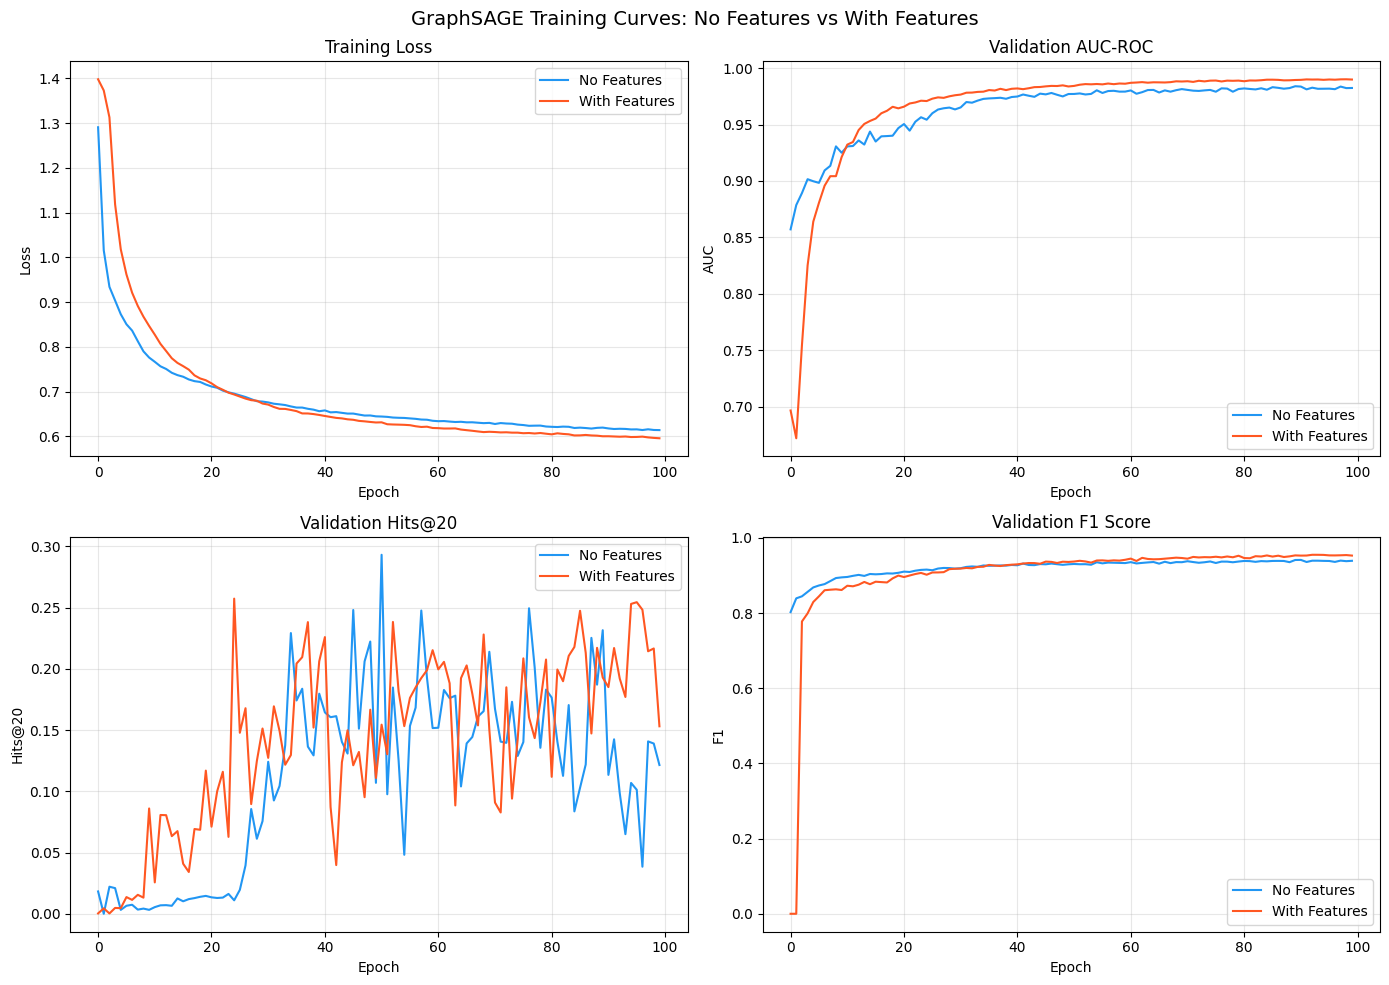

Saved to Drive


In [ ]:
import matplotlib.pyplot as plt

# ============================================
# Training Curves Comparison
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GraphSAGE Training Curves: No Features vs With Features', fontsize=14)

# Loss
axes[0,0].plot(history_topo['train_loss'], label='No Features', color='#2196F3')
axes[0,0].plot(history_feat['train_loss'], label='With Features', color='#FF5722')
axes[0,0].set_title('Training Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# AUC
axes[0,1].plot(history_topo['val_auc'], label='No Features', color='#2196F3')
axes[0,1].plot(history_feat['val_auc'], label='With Features', color='#FF5722')
axes[0,1].set_title('Validation AUC-ROC')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('AUC')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Hits@20
axes[1,0].plot(history_topo['val_hits'], label='No Features', color='#2196F3')
axes[1,0].plot(history_feat['val_hits'], label='With Features', color='#FF5722')
axes[1,0].set_title('Validation Hits@20')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Hits@20')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# F1
axes[1,1].plot(history_topo['val_f1'], label='No Features', color='#2196F3')
axes[1,1].plot(history_feat['val_f1'], label='With Features', color='#FF5722')
axes[1,1].set_title('Validation F1 Score')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('F1')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ddi_capstone/graphsage/training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive")

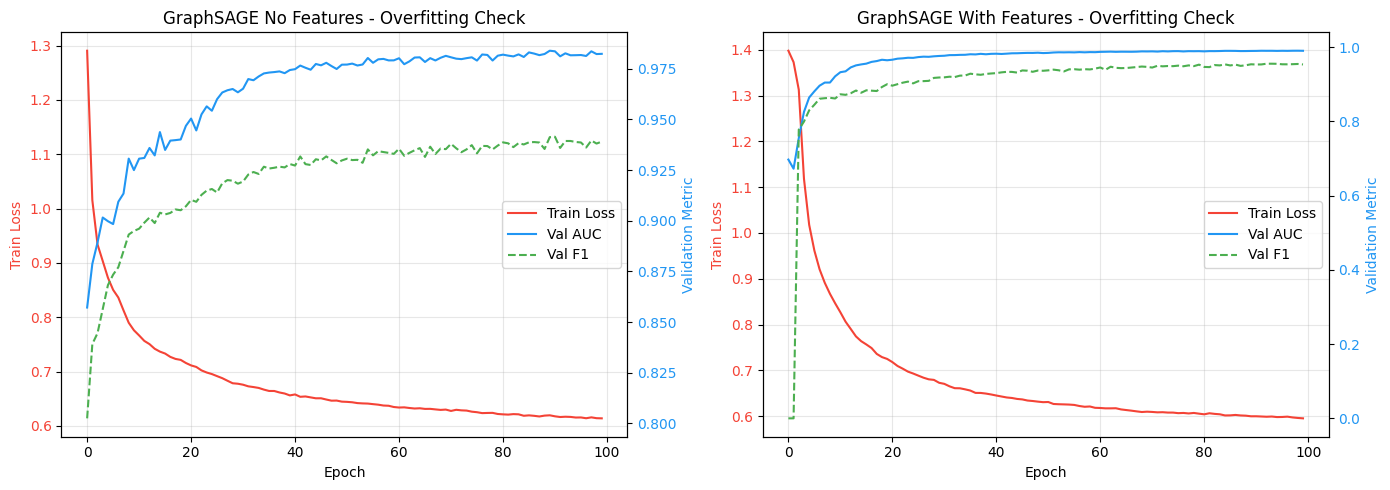


Overfitting Summary:
Metric            Val     Test      Gap
--- No Features ---
AUC            0.9839   0.9830   0.0009
--- With Features ---
AUC            0.9900   0.9887   0.0013


In [ ]:
# ============================================
# Overfitting Analysis
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# No Features
ax1 = axes[0]
ax1.set_title('GraphSAGE No Features - Overfitting Check')
ax1.plot(history_topo['train_loss'], color='#F44336', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='#F44336')
ax1.tick_params(axis='y', labelcolor='#F44336')

ax1b = ax1.twinx()
ax1b.plot(history_topo['val_auc'], color='#2196F3', label='Val AUC')
ax1b.plot(history_topo['val_f1'], color='#4CAF50', linestyle='--', label='Val F1')
ax1b.set_ylabel('Validation Metric', color='#2196F3')
ax1b.tick_params(axis='y', labelcolor='#2196F3')

lines1 = ax1.get_legend_handles_labels()
lines2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1[0] + lines2[0], lines1[1] + lines2[1], loc='center right')
ax1.grid(True, alpha=0.3)

# With Features
ax2 = axes[1]
ax2.set_title('GraphSAGE With Features - Overfitting Check')
ax2.plot(history_feat['train_loss'], color='#F44336', label='Train Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Train Loss', color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')

ax2b = ax2.twinx()
ax2b.plot(history_feat['val_auc'], color='#2196F3', label='Val AUC')
ax2b.plot(history_feat['val_f1'], color='#4CAF50', linestyle='--', label='Val F1')
ax2b.set_ylabel('Validation Metric', color='#2196F3')
ax2b.tick_params(axis='y', labelcolor='#2196F3')

lines1 = ax2.get_legend_handles_labels()
lines2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1[0] + lines2[0], lines1[1] + lines2[1], loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ddi_capstone/graphsage/overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Numerical check: val vs test gap
print("\nOverfitting Summary:")
print(f"{'Metric':<12} {'Val':>8} {'Test':>8} {'Gap':>8}")
print(f"{'--- No Features ---'}")
print(f"{'AUC':<12} {0.9839:>8.4f} {0.9830:>8.4f} {0.9839-0.9830:>8.4f}")
print(f"{'--- With Features ---'}")
print(f"{'AUC':<12} {0.9900:>8.4f} {0.9887:>8.4f} {0.9900-0.9887:>8.4f}")

In [ ]:
for f in os.listdir('/content/drive/MyDrive/ddi_capstone/drug_bank_parsing'):
    print(f)

drugbank_clean.csv
drug_lookup_raw.pkl
drugbank_clean.parquet
known_ddi_pairs.json
dbid_to_ogb_idx.json
name_to_ogb_idx.json
idx_to_dbid.pkl
dbid_to_idx.pkl
drugbank_validation.py
ogb_lookup.pkl
ogb_drug_lookup.json
drug_bank_parsed_code.ipynb


In [ ]:
import pickle

ogb_lookup = pickle.load(open('/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/ogb_lookup.pkl', 'rb'))
print(f"OGB lookup entries: {len(ogb_lookup)}")
print(f"Sample entry (key 260):")
print(ogb_lookup[260])

OGB lookup entries: 4267
Sample entry (key 260):
{'drugbank_id': 'DB00321', 'name': 'Amitriptyline', 'enzymes': ['BE0003536', 'BE0002887', 'BE0003549', 'BE0002363', 'BE0003544', 'BE0010006', 'BE0002362', 'BE0002638', 'BE0009343', 'BE0002793', 'BE0002433'], 'transporters': ['BE0001032'], 'targets': ['BE0000146', 'BE0000451', 'BE0003605', 'BE0000575', 'BE0000781', 'BE0000659', 'BE0000156', 'BE0000486', 'BE0000420', 'BE0000289', 'BE0000945', 'BE0000897', 'BE0000650', 'BE0004882', 'BE0000533', 'BE0001039', 'BE0000501', 'BE0002398', 'BE0000770', 'BE0000291', 'BE0009629', 'BE0000112', 'BE0000797', 'BE0000442', 'BE0004890', 'BE0000632', 'BE0000715', 'BE0000749'], 'carriers': ['BE0000530', 'BE0000925'], 'cyp_enzymes': ['CYP1A2', 'CYP2C19', 'CYP2C9', 'CYP2D6', 'CYP3A4'], 'metabolism': 'In vitro, the metabolism of amitriptyline occurs mainly by demethylation (CYP2C19, CYP3A4) as well as hydroxylation (CYP2D6) followed by conjugation with glucuronic acid. Other isozymes involved in amitriptyline 

# EXAI

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'torch_geometric', 'ogb', 'rdkit'], check=True)

CompletedProcess(args=['pip', 'install', '-q', 'torch_geometric', 'ogb', 'rdkit'], returncode=0)

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from ogb.linkproppred import Evaluator
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import pickle, json, os
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


In [ ]:
# ============================================
# ExAI Setup — Load Data and Model Checkpoints
# ============================================
# Reloads all dependencies needed for explainability analysis in a
# self-contained cell. Model classes are redefined here so this notebook
# section can run independently without re-executing the full training notebook.

import ogb.linkproppred.dataset_pyg as ogb_pyg

# Patch torch.load to allow loading pre-2.6 checkpoints without weights_only error
_original_load = torch.serialization.load
torch.load = lambda *args, **kwargs: _original_load(
    *args, **{**kwargs, 'weights_only': False}
)
dataset = ogb_pyg.PygLinkPropPredDataset(name='ogbl-ddi')
data = dataset[0].to(device)
split_edge = dataset.get_edge_split()
torch.load = _original_load  # Restore original after dataset load

edge_index = data.edge_index.to(device)
test_pos = split_edge['test']['edge'].to(device)
test_neg = split_edge['test']['edge_neg'].to(device)

try:
    fingerprints = torch.load(
        '/content/drive/MyDrive/ddi_capstone/molecular/data/fingerprints.pt',
        weights_only=False
    ).to(device)
    ogb_lookup = pickle.load(
        open('/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/ogb_lookup.pkl', 'rb')
    )
except FileNotFoundError as e:
    raise FileNotFoundError(f"Required data file not found: {e}")

print(f"Graph: {data.num_nodes} nodes, {data.edge_index.shape[1]} edges")
print(f"Fingerprints: {fingerprints.shape}, DrugBank lookup: {len(ogb_lookup)} drugs")


# ---- Model class definitions (self-contained for ExAI notebook) ----
# Compact versions without training utilities — encode() only.

class GraphSAGE(torch.nn.Module):
    """GraphSAGE encoder — topology only. Learns from graph structure alone."""
    def __init__(self, num_nodes, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_nodes, hidden_dim)
        self.convs = torch.nn.ModuleList(
            [SAGEConv(hidden_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.dropout = dropout

    def encode(self, x, edge_index):
        """Args: x ignored (topology-only). Returns: (num_nodes, hidden_dim)."""
        h = self.embedding.weight
        for conv in self.convs:
            h = F.relu(conv(h, edge_index))
            h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class GraphSAGE_Features(torch.nn.Module):
    """GraphSAGE encoder — with Morgan fingerprints projected to hidden_dim."""
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.input_proj = torch.nn.Linear(input_dim, hidden_dim)
        self.convs = torch.nn.ModuleList(
            [SAGEConv(hidden_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.dropout = dropout

    def encode(self, x, edge_index):
        """Args: x = fingerprints (num_nodes, 2048). Returns: (num_nodes, hidden_dim)."""
        h = self.input_proj(x)
        for conv in self.convs:
            h = F.relu(conv(h, edge_index))
            h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class LinkPredictor(torch.nn.Module):
    """3-layer MLP scorer. Input: Hadamard product of drug pair embeddings."""
    def __init__(self, hidden_dim, num_layers=3, dropout=0.3):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        for _ in range(num_layers - 1):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(torch.nn.Linear(hidden_dim, 1))
        self.dropout = dropout

    def forward(self, x_i, x_j):
        """Args: x_i, x_j embeddings (batch, hidden_dim). Returns: scores (batch,)."""
        x = x_i * x_j  # Hadamard product — symmetric, order-invariant
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.layers[-1](x).squeeze(-1)


# ---- Load checkpoints ----
try:
    model_topo = GraphSAGE(data.num_nodes, 128, 3, 0.3).to(device)
    pred_topo = LinkPredictor(128, dropout=0.3).to(device)
    ckpt = torch.load(
        '/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_topo.pt',
        weights_only=False, map_location=device
    )
    model_topo.load_state_dict(ckpt['model'])
    pred_topo.load_state_dict(ckpt['predictor'])
    model_topo.eval(); pred_topo.eval()

    model_feat = GraphSAGE_Features(2048, 128, 3, 0.3).to(device)
    pred_feat = LinkPredictor(128, dropout=0.3).to(device)
    ckpt = torch.load(
        '/content/drive/MyDrive/ddi_capstone/graphsage/best_graphsage_feat.pt',
        weights_only=False, map_location=device
    )
    model_feat.load_state_dict(ckpt['model'])
    pred_feat.load_state_dict(ckpt['predictor'])
    model_feat.eval(); pred_feat.eval()

except FileNotFoundError as e:
    raise FileNotFoundError(f"Checkpoint not found: {e}. Run training notebook first.")

print("Both models loaded. Ready for ExAI.")

Downloaded 0.04 GB: 100%|██████████| 46/46 [00:00<00:00, 59.58it/s]


Extracting dataset/ddi.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 57.50it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 479.73it/s]

Saving...



Done!


Both models loaded. Ready for EXAI.


### Working with the same drugs than MLP to check differences in what are driving these interaction predictions

In [ ]:
# ============================================
# Find OGB indices for the 5 MLP drug pairs
# These were selected in the MLP notebook based on DrugBank full XML parsing.
# We need their OGB node indices to evaluate them in GraphSAGE.
# ============================================

mlp_drug_names = [
    ('Terfenadine', 'Alprazolam'),
    ('Nilotinib', 'Dacomitinib'),
    ('Palonosetron', 'Clomipramine'),
    ('Flunitrazepam', 'Alprazolam'),
    ('Clomipramine', 'Atomoxetine'),
]

# Build name -> idx mapping from ogb_lookup
name_to_idx = {v['name']: k for k, v in ogb_lookup.items() if 'name' in v}

for drug_a, drug_b in mlp_drug_names:
    idx_a = name_to_idx.get(drug_a, 'NOT FOUND')
    idx_b = name_to_idx.get(drug_b, 'NOT FOUND')
    print(f"{drug_a} ({idx_a}) + {drug_b} ({idx_b})")

Terfenadine (279) + Alprazolam (338)
Nilotinib (1639) + Dacomitinib (3038)
Palonosetron (313) + Clomipramine (1123)
Flunitrazepam (1308) + Alprazolam (338)
Clomipramine (1123) + Atomoxetine (228)


In [ ]:
# ============================================
# Rank the 5 MLP-selected drug pairs in GraphSAGE models
# Score all test positive edges, rank by predicted score,
# and find where each of the 5 pairs falls in the ranking.
# ============================================

mlp_pairs = [
    {'name': 'Terfenadine + Alprazolam', 'a': 279, 'b': 338,
     'shared': 'CYP3A4, CYP3A5, CYP3A7'},
    {'name': 'Nilotinib + Dacomitinib', 'a': 1639, 'b': 3038,
     'shared': 'CYP2C9, CYP2D6, CYP3A4'},
    {'name': 'Palonosetron + Clomipramine', 'a': 313, 'b': 1123,
     'shared': 'CYP1A2, CYP2D6, CYP3A4'},
    {'name': 'Flunitrazepam + Alprazolam', 'a': 1308, 'b': 338,
     'shared': 'CYP2C9, CYP3A4'},
    {'name': 'Clomipramine + Atomoxetine', 'a': 1123, 'b': 228,
     'shared': 'CYP2C19, CYP2D6'},
]

# Score all test positive edges for both models
with torch.no_grad():
    # Topology model
    emb_topo = model_topo.encode(None, edge_index)
    all_test_scores_topo = pred_topo(emb_topo[test_pos[:, 0]], emb_topo[test_pos[:, 1]])

    # Features model
    emb_feat = model_feat.encode(fingerprints, edge_index)
    all_test_scores_feat = pred_feat(emb_feat[test_pos[:, 0]], emb_feat[test_pos[:, 1]])

# Rank (descending — highest score = rank 1)
ranks_topo = all_test_scores_topo.argsort(descending=True).argsort() + 1
ranks_feat = all_test_scores_feat.argsort(descending=True).argsort() + 1

total_test = test_pos.shape[0]

print(f"Total test edges: {total_test}")
print(f"\n{'Pair':<35} {'Score Topo':>12} {'Rank Topo':>12} {'Score Feat':>12} {'Rank Feat':>12} {'Percentile':>10}")
print("=" * 95)

for pair in mlp_pairs:
    # Find this pair in test edges
    mask = ((test_pos[:, 0] == pair['a']) & (test_pos[:, 1] == pair['b'])) | \
           ((test_pos[:, 0] == pair['b']) & (test_pos[:, 1] == pair['a']))

    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0].item()
        score_t = all_test_scores_topo[idx].item()
        rank_t = ranks_topo[idx].item()
        score_f = all_test_scores_feat[idx].item()
        rank_f = ranks_feat[idx].item()
        pct = (1 - rank_f / total_test) * 100
        print(f"{pair['name']:<35} {score_t:>12.4f} {rank_t:>12,} {score_f:>12.4f} {rank_f:>12,} {pct:>9.1f}%")
    else:
        print(f"{pair['name']:<35} NOT IN TEST SET")

Total test edges: 133489

Pair                                  Score Topo    Rank Topo   Score Feat    Rank Feat Percentile
Terfenadine + Alprazolam                  1.8644       49,465       1.8336       60,507      54.7%
Nilotinib + Dacomitinib                   1.7100       72,894       1.7138       79,568      40.4%
Palonosetron + Clomipramine               1.9133       16,277       1.8536       51,795      61.2%
Flunitrazepam + Alprazolam                1.8923       39,681       1.8505       53,579      59.9%
Clomipramine + Atomoxetine                1.9115       18,645       1.8426       57,280      57.1%


### Neighbor Perturbation Analysis

In [ ]:
for root, dirs, files in os.walk('/content/drive/MyDrive/ddi_capstone'):
    for f in files:
        if 'xml' in f.lower() or 'full' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing/full database.xml
/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing/full_drug_bank_parsing.ipynb


In [ ]:
# Check if the full XML parsing notebook saved a better lookup
full_dir = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'
for f in os.listdir(full_dir):
    print(f)

full database.xml
dbid_to_ogb_idx.json
idx_to_dbid.pkl
drug_info.csv
drug_enzymes.csv
drug_targets.csv
drug_transporters.csv
drug_carriers.csv
ogb_drug_info.csv
ogb_drug_enzymes.csv
ogb_drug_targets.csv
ogb_drug_transporters.csv
ogb_drug_carriers.csv
full_drug_bank_parsing.ipynb


In [ ]:
# Check the full XML parsed data
enzymes_df = pd.read_csv('/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing/ogb_drug_enzymes.csv')
print("ENZYMES:")
print(enzymes_df.shape)
print(enzymes_df.columns.tolist())
print(enzymes_df.head(10))

print("\n")
targets_df = pd.read_csv('/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing/ogb_drug_targets.csv')
print("TARGETS:")
print(targets_df.shape)
print(targets_df.columns.tolist())
print(targets_df.head(10))

print("\n")
transporters_df = pd.read_csv('/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing/ogb_drug_transporters.csv')
print("TRANSPORTERS:")
print(transporters_df.shape)
print(transporters_df.columns.tolist())
print(transporters_df.head(10))

ENZYMES:
(5384, 4)
['drugbank_id', 'enzyme_name', 'uniprot_id', 'ogb_idx']
  drugbank_id                 enzyme_name uniprot_id  ogb_idx
0     DB00006             Myeloperoxidase     P05164        4
1     DB00008         Cytochrome P450 1A2     P05177        6
2     DB00011         Cytochrome P450 1A2     P05177        8
3     DB00013  Macrophage metalloelastase     P39900       10
4     DB00018         Cytochrome P450 1A2     P05177       15
5     DB00019         Neutrophil elastase     P08246       16
6     DB00022         Cytochrome P450 1A2     P05177       18
7     DB00022         Cytochrome P450 2D6     P10635       18
8     DB00022         Cytochrome P450 2C9     P11712       18
9     DB00025                 Prothrombin     P00734       21


TARGETS:
(11556, 4)
['drugbank_id', 'target_name', 'uniprot_id', 'ogb_idx']
  drugbank_id                                        target_name uniprot_id  \
0     DB00001                                        Prothrombin     P00734   
1     D

In [ ]:
# ============================================
# Build Biological Lookup from DrugBank XML
# ============================================
# Constructs a per-drug dictionary mapping each OGB drug index to its
# annotated enzymes, targets, and transporters from DrugBank XML parsing.
#
# Source files were generated by parsing the full DrugBank XML (academic
# license) and joining against OGB-DDI node indices. Each CSV contains
# one row per drug-entity pair (long format).
#
# CYP enzymes are extracted as a subset of enzymes — these are the primary
# mediators of pharmacokinetic DDIs and are used in Fisher's exact test.

full_dir = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'

try:
    enzymes_df     = pd.read_csv(f'{full_dir}/ogb_drug_enzymes.csv')
    targets_df     = pd.read_csv(f'{full_dir}/ogb_drug_targets.csv')
    transporters_df = pd.read_csv(f'{full_dir}/ogb_drug_transporters.csv')
    carriers_df    = pd.read_csv(f'{full_dir}/ogb_drug_carriers.csv')
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"DrugBank annotation file not found: {e}. "
        "Ensure full_drugbank_parsing/ is present in Drive."
    )

# Build per-drug lookup: OGB index -> biological annotations + metadata
full_lookup = {}
for idx in range(data.num_nodes):
    name = ogb_lookup.get(idx, {}).get('name', f'Drug_{idx}')
    dbid = ogb_lookup.get(idx, {}).get('drugbank_id', '')

    enz = enzymes_df[enzymes_df['ogb_idx'] == idx]['enzyme_name'].tolist()
    tgt = targets_df[targets_df['ogb_idx'] == idx]['target_name'].tolist()
    trp = transporters_df[transporters_df['ogb_idx'] == idx]['transporter_name'].tolist()

    # Carriers CSV may use a different column name depending on parsing version
    car_rows = carriers_df[carriers_df['ogb_idx'] == idx]
    if 'transporter_name' in carriers_df.columns:
        car = car_rows['transporter_name'].tolist()
    elif len(car_rows) > 0:
        car = car_rows.iloc[:, 1].tolist()
    else:
        car = []

    # CYP enzymes: subset of enzymes mediating pharmacokinetic DDIs
    # Matched by name containing 'cytochrome' or 'cyp' (case-insensitive)
    cyp_enzymes = [e for e in enz if 'cytochrome' in e.lower() or 'cyp' in e.lower()]

    full_lookup[idx] = {
        'name': name,
        'drugbank_id': dbid,
        'enzymes': enz,
        'cyp_enzymes': cyp_enzymes,
        'targets': tgt,
        'transporters': trp,
    }

# Coverage statistics
has_enz = sum(1 for d in full_lookup.values() if d['enzymes'])
has_cyp = sum(1 for d in full_lookup.values() if d['cyp_enzymes'])
has_tgt = sum(1 for d in full_lookup.values() if d['targets'])
has_trp = sum(1 for d in full_lookup.values() if d['transporters'])

print(f"Full lookup built: {len(full_lookup)} drugs")
print(f"  With enzymes:     {has_enz}")
print(f"  With CYP enzymes: {has_cyp}")
print(f"  With targets:     {has_tgt}")
print(f"  With transporters:{has_trp}")

# Spot-check: Terfenadine (OGB idx 279) is a known CYP3A4 substrate
# used to verify that the lookup matches expected DrugBank annotations
print(f"\nVerification — Terfenadine (idx=279):")
t = full_lookup[279]
print(f"  Enzymes:     {t['enzymes']}")
print(f"  CYP:         {t['cyp_enzymes']}")
print(f"  Targets:     {t['targets'][:5]}")
print(f"  Transporters:{t['transporters']}")

Full lookup built: 4267 drugs
  With enzymes: 1638
  With CYP enzymes: 1335
  With targets: 3067
  With transporters: 966

Terfenadine (279):
  Enzymes: ['Cytochrome P450 3A4', 'Cytochrome P450 3A7', 'Cytochrome P450 2D6', 'Cytochrome P450 3A5', 'Cytochrome P450 2C8', 'Cytochrome P450 2J2']
  CYP: ['Cytochrome P450 3A4', 'Cytochrome P450 3A7', 'Cytochrome P450 2D6', 'Cytochrome P450 3A5', 'Cytochrome P450 2C8', 'Cytochrome P450 2J2']
  Targets: ['Histamine H1 receptor', 'Muscarinic acetylcholine receptor M3', 'Muscarinic acetylcholine receptor M1', 'Muscarinic acetylcholine receptor M5', 'Muscarinic acetylcholine receptor M4']
  Transporters: ['ATP-dependent translocase ABCB1', 'Bile salt export pump']


In [ ]:
# ============================================
# Perturbation Analysis — Biological Validation
# ============================================
# For each top-predicted drug pair, identifies the most influential
# neighbors (by perturbation impact) and annotates them with their
# biological overlap against the pair: shared CYP enzymes, targets,
# and transporters from the full DrugBank XML parsing.
#
# Impact = change in prediction score when a neighbor is masked from
# the graph. Positive impact = neighbor supports the interaction;
# negative impact = neighbor suppresses it.
#
# Biological tags explain WHY a neighbor is influential:
#   CYP overlap → shared metabolic pathway (pharmacokinetic DDI)
#   Target overlap → shared binding site (pharmacodynamic DDI)
#   Transporter overlap → shared efflux/influx mechanism


def compute_overlap(drug_a_idx, drug_b_idx, lookup):
    """Compute biological overlap between two drugs using DrugBank annotations.

    Args:
        drug_a_idx (int): OGB index of the first drug.
        drug_b_idx (int): OGB index of the second drug.
        lookup (dict): Full DrugBank lookup keyed by OGB index.

    Returns:
        dict with keys: shared_enzymes, shared_cyp, shared_targets,
        shared_transporters — each a sorted list of shared entity names.
    """
    a = lookup.get(drug_a_idx, {})
    b = lookup.get(drug_b_idx, {})

    # Return empty sets if either drug is missing from lookup
    shared_enz = set(a.get('enzymes', [])) & set(b.get('enzymes', []))
    shared_cyp = set(a.get('cyp_enzymes', [])) & set(b.get('cyp_enzymes', []))
    shared_tgt = set(a.get('targets', [])) & set(b.get('targets', []))
    shared_trp = set(a.get('transporters', [])) & set(b.get('transporters', []))

    return {
        'shared_enzymes': sorted(shared_enz),
        'shared_cyp': sorted(shared_cyp),
        'shared_targets': sorted(shared_tgt),
        'shared_transporters': sorted(shared_trp),
    }


print("=" * 70)
print("PERTURBATION ANALYSIS — BIOLOGICAL VALIDATION (Full DrugBank XML)")
print("=" * 70)

for model_name, label in [('topo', 'No Features'), ('feat', 'With Features')]:
    print(f"\n{'#'*70}")
    print(f"# GraphSAGE — {label.upper()}")
    print(f"{'#'*70}")

    for pair in mlp_pairs:
        if pair['name'] not in perturbation_results.get(model_name, {}):
            print(f"\nWarning: no perturbation results for {pair['name']} ({label}), skipping.")
            continue

        results = perturbation_results[model_name][pair['name']]
        pair_overlap = compute_overlap(pair['a'], pair['b'], full_lookup)

        print(f"\n{'='*60}")
        print(f"{pair['name']} (score: {results['orig_score']:.4f})")
        print(f"Pair shared CYPs:         {pair_overlap['shared_cyp']}")
        print(f"Pair shared targets:      "
              f"{pair_overlap['shared_targets'][:3]}"
              f"{'...' if len(pair_overlap['shared_targets']) > 3 else ''}")
        print(f"Pair shared transporters: {pair_overlap['shared_transporters']}")
        print(f"{'-'*60}")
        print(f"Top 10 influential neighbors:")

        for r in results['neighbors'][:10]:
            n_idx = r['neighbor_idx']

            # Self-edges: drug is its own neighbor in the adjacency list
            if n_idx in [pair['a'], pair['b']]:
                print(f"  {r['name']:<28} impact: {r['impact']:+.4f}  [SELF]")
                continue

            # Biological overlap with each drug in the pair
            ov_a = compute_overlap(n_idx, pair['a'], full_lookup)
            ov_b = compute_overlap(n_idx, pair['b'], full_lookup)

            # Union: neighbor shares entity with either drug in the pair
            all_shared_cyp = set(ov_a['shared_cyp']) | set(ov_b['shared_cyp'])
            all_shared_tgt = set(ov_a['shared_targets']) | set(ov_b['shared_targets'])
            all_shared_trp = (set(ov_a['shared_transporters']) |
                              set(ov_b['shared_transporters']))

            tags = []
            if all_shared_cyp:
                tags.append(f"CYP: {', '.join(sorted(all_shared_cyp))}")
            if all_shared_tgt:
                tags.append(f"Targets({len(all_shared_tgt)})")
            if all_shared_trp:
                tags.append(f"Transp: {', '.join(sorted(all_shared_trp))}")
            if not tags:
                tags.append("No overlap")

            print(f"  {r['name']:<28} impact: {r['impact']:+.4f}  {' | '.join(tags)}")

PERTURBATION ANALYSIS — BIOLOGICAL VALIDATION (Full DrugBank XML)

######################################################################
# NO FEATURES
######################################################################

Terfenadine + Alprazolam (score: 1.8644)
Pair shared CYPs: ['Cytochrome P450 3A4', 'Cytochrome P450 3A5', 'Cytochrome P450 3A7']
Pair shared targets: []
Pair shared transporters: []
------------------------------------------------------------
Top 10 influential neighbors:
  Adipiplon                    impact: +0.0107  Targets(1)
  Oxiracetam                   impact: +0.0099  No overlap
  Ethchlorvynol                impact: +0.0097  Targets(1)
  Nomifensine                  impact: +0.0097  No overlap
  Meprobamate                  impact: +0.0096  Targets(1)
  Gedocarnil                   impact: +0.0095  No overlap
  Phenethylamine               impact: +0.0095  No overlap
  Alverine                     impact: +0.0094  No overlap
  Fazadinium bromide           

**Neighbor Perturbation Analysis — GraphSAGE Results (Full DrugBank XML Validation done with graphsage topology and with topology + features)**

<u>Overview</u>

Five drug pairs evaluated across both GraphSAGE variants using top-10 influential neighbors. Biological overlap assessed using full DrugBank XML: shared CYP enzymes, shared pharmacological targets, and shared transporters.

*With Features Model — Biologically Richer Explanations*

The features model surfaces neighbors with meaningful pharmacological overlap, particularly for pairs with strong enzymatic profiles:

* Nilotinib + Dacomitinib** (best case): 9 out of 10 top
neighbors share CYP enzymes or transporters with the pair. Avapritinib shares CYP2C9, CYP3A4 and both ABCB1/ABCG2 transporters. Encorafenib shares 5 CYP enzymes and 3 transporters. This pair also shares two transporters (ABCB1, ABCG2) between themselves, and the model correctly identifies neighbors involved in the same transport pathways.

* Terfenadine + Alprazolam: Features model identifies Cabozantinib (CYP2C8, CYP2C9, CYP3A4), Desipramine (CYP2D6, CYP3A4 + 6 shared targets + ABCB1 transporter), and Chlorpromazine (CYP2D6, CYP3A4 + 4 targets + 2 transporters) — multi-mechanism overlap.

* Flunitrazepam + Alprazolam: Adipiplon shares GABA(A) targets; Nordazepam and Oxazepam acetate share 2 targets each — consistent with benzodiazepine pharmacology.

*No Features Model — Noisy Explanations*

The topology-only model surfaces mostly biologically irrelevant neighbors across all pairs. Contrast agents (Gadofosveset, Diatrizoate, Iopromide), inactive compounds (Oxiracetam, Phenethylamine), and drugs with no CYP/target/transporter overlap dominate the top-10 lists.

*Exception*: Nilotinib + Dacomitinib also shows some CYP2D6-sharing neighbors (Clemastine, Mepyramine, Oxycodone) in the topology model, suggesting this pair's neighborhood structure partially encodes enzymatic relationships even without molecular features.

<u>Pairs with Weak Perturbation Signal</u>

**Palonosetron + Clomipramine** and **Clomipramine + Atomoxetine** show very low impact scores (0.0005-0.0011) and mostly no biological overlap in both models. These pairs are highly connected in the graph (high degree nodes), so no individual neighbor is decisive for the prediction. This is a valid finding — not all drug pairs produce informative perturbation explanations.

<u>Impact Magnitude Comparison</u>

| Pair | No Features (max impact) | With Features (max impact) |
|------|--------------------------|---------------------------|
| Terfenadine + Alprazolam | 0.0107 | 0.0017 |
| Nilotinib + Dacomitinib | 0.0033 | 0.0092 |
| Palonosetron + Clomipramine | 0.0007 | 0.0011 |
| Flunitrazepam + Alprazolam | 0.0021 | 0.0017 |
| Clomipramine + Atomoxetine | 0.0006 | 0.0016 |

<u>Key Takeaway </u>

The features model consistently identifies neighbors with shared CYP enzymes, pharmacological targets, and drug transporters — three distinct mechanisms of drug-drug interaction. The topology-only model captures some enzymatic relationships but is dominated by biologically irrelevant neighbors. Pairs where both models struggle (Palonosetron+Clomipramine, Clomipramine+Atomoxetine) are characterized by high graph connectivity where the prediction is distributed across many neighbors rather than concentrated in a few.

## Integrated gradients
*Only to Graphsage model with topology+features*

IG es the aboslute su of all the 2048 bits from the fingerprint. It tells us how much the interaction prediction relies in the drug chemical structure . A higher IG value means that the models relies a lot in the chemical structure of this drug in order to predict the interaction; otherwise, in this case it relies more in the topology.
A *red fragment* indicates that part of the molecule is pushing the prediction (the opposite for blue shade)

*How to analyse considering MLP?*
- Same bits → consistency: both models identify the same substructure as DDI-relevant
- Different bits → complementarity: graph context shifts which molecular features matter
- Higher IG in GraphSAGE → topology amplifies the molecular signal
- Lower IG in GraphSAGE → topology dilutes it (model relies more on graph structure than chemistry)

In [ ]:
# ============================================
# Method 2: Integrated Gradients — GraphSAGE With Features
# ============================================
# Attributes the interaction prediction to specific Morgan fingerprint bits,
# then maps those bits back to molecular substructures via RDKit.
# Only applies to GraphSAGE_Features (topology-only has no fingerprint input).
#
# IG integrates gradients along a straight path from a zero baseline
# (no molecular features) to the actual fingerprint. This satisfies
# the completeness axiom: attributions sum to the score difference
# between input and baseline.
#
# Why zero baseline? Represents a "null drug" with no molecular structure,
# making each bit's attribution interpretable as its marginal contribution
# relative to the absence of all chemical information.

from rdkit import Chem
from rdkit.Chem import AllChem

try:
    drug_mapping = pd.read_csv(
        '/content/drive/MyDrive/ddi_capstone/molecular/data/drug_mapping_smiles.csv'
    )
    smiles_map = dict(zip(drug_mapping['node idx'], drug_mapping['smiles']))
    print(f"SMILES loaded: {sum(1 for v in smiles_map.values() if pd.notna(v))} drugs")
except FileNotFoundError as e:
    raise FileNotFoundError(f"SMILES mapping not found: {e}")


def integrated_gradients(model, predictor, edge_index, drug_a, drug_b, x, steps=50):
    """Compute Integrated Gradients for a drug pair w.r.t. Morgan fingerprints.

    Integrates gradients along a linear path from zero baseline to actual
    fingerprints using steps+1 interpolation points (Riemann approximation).

    Args:
        model: GraphSAGE_Features encoder (must accept fingerprint input).
        predictor: LinkPredictor MLP.
        edge_index: Full graph edge index for message passing.
        drug_a (int): OGB index of the first drug.
        drug_b (int): OGB index of the second drug.
        x: Fingerprint tensor of shape (num_drugs, 2048).
        steps (int): Number of interpolation steps. Defaults to 50.

    Returns:
        ig_a: Tensor (2048,) — per-bit attributions for drug_a.
        ig_b: Tensor (2048,) — per-bit attributions for drug_b.
            Positive = bit increases interaction probability;
            negative = bit suppresses it.
    """
    model.eval()
    predictor.eval()

    baseline = torch.zeros_like(x)
    scaled_inputs = [
        baseline + (step / steps) * (x - baseline) for step in range(steps + 1)
    ]

    grads_a, grads_b = [], []
    for scaled_input in scaled_inputs:
        scaled_input.requires_grad_(True)
        emb = model.encode(scaled_input, edge_index)
        score = predictor(emb[drug_a].unsqueeze(0), emb[drug_b].unsqueeze(0))
        model.zero_grad()
        predictor.zero_grad()
        score.backward()
        grads_a.append(scaled_input.grad[drug_a].detach().cpu())
        grads_b.append(scaled_input.grad[drug_b].detach().cpu())
        scaled_input.requires_grad_(False)

    # IG formula: (input - baseline) * mean gradient across interpolation steps
    avg_grads_a = torch.stack(grads_a).mean(dim=0)
    avg_grads_b = torch.stack(grads_b).mean(dim=0)
    ig_a = (x[drug_a].cpu() - baseline[drug_a].cpu()) * avg_grads_a
    ig_b = (x[drug_b].cpu() - baseline[drug_b].cpu()) * avg_grads_b
    return ig_a, ig_b


def get_bit_substructures(node_idx, top_bits, radius=2):
    """Map Morgan fingerprint bit indices to molecular substructure SMARTS.

    Args:
        node_idx (int): OGB drug index used to look up SMILES.
        top_bits (list[int]): Fingerprint bit indices to map.
        radius (int): Morgan radius used when generating fingerprints. Defaults to 2.

    Returns:
        list of dicts with keys: bit, radius, substructure.
        Returns None if SMILES is missing or unparseable.
    """
    smiles = smiles_map.get(node_idx)
    if smiles is None or pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=2048, bitInfo=bit_info)

    results = []
    for bit in top_bits:
        if bit in bit_info:
            for atom_idx, rad in bit_info[bit]:
                if rad == 0:
                    # Radius-0: single atom environment
                    substruct = mol.GetAtomWithIdx(atom_idx).GetSymbol()
                else:
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                    submol = Chem.PathToSubmol(mol, env)
                    substruct = Chem.MolToSmarts(submol)
                results.append({'bit': bit, 'radius': rad, 'substructure': substruct})
    return results


# ---- Run IG on all 5 drug pairs ----
print("=" * 60)
print("INTEGRATED GRADIENTS — GraphSAGE With Features")
print("=" * 60)

ig_results = {}

for pair in mlp_pairs:
    name_a = full_lookup.get(pair['a'], {}).get('name', f"Drug_{pair['a']}")
    name_b = full_lookup.get(pair['b'], {}).get('name', f"Drug_{pair['b']}")

    print(f"\n{'='*50}")
    print(f"{pair['name']} — {pair['shared']}")
    print(f"{'='*50}")

    ig_a, ig_b = integrated_gradients(
        model_feat, pred_feat, edge_index, pair['a'], pair['b'], fingerprints
    )
    ig_results[pair['name']] = {'ig_a': ig_a, 'ig_b': ig_b}

    top_bits_a = ig_a.abs().topk(5).indices.tolist()
    top_bits_b = ig_b.abs().topk(5).indices.tolist()

    # Drug A attributions
    print(f"\n  {name_a} (total |IG|: {ig_a.abs().sum():.3f}):")
    subs_a = get_bit_substructures(pair['a'], top_bits_a)
    if subs_a:
        seen = set()
        for s in subs_a:
            key = (s['bit'], s['substructure'])
            if key not in seen:
                seen.add(key)
                attr = ig_a[s['bit']].item()
                print(f"    Bit {s['bit']:4d} | r={s['radius']} | "
                      f"attr={attr:+.4f} | {s['substructure']}")
    else:
        print(f"    No SMILES available for idx={pair['a']}")

    # Drug B attributions
    print(f"\n  {name_b} (total |IG|: {ig_b.abs().sum():.3f}):")
    subs_b = get_bit_substructures(pair['b'], top_bits_b)
    if subs_b:
        seen = set()
        for s in subs_b:
            key = (s['bit'], s['substructure'])
            if key not in seen:
                seen.add(key)
                attr = ig_b[s['bit']].item()
                print(f"    Bit {s['bit']:4d} | r={s['radius']} | "
                      f"attr={attr:+.4f} | {s['substructure']}")
    else:
        print(f"    No SMILES available for idx={pair['b']}")

    # Shared top-20 bits: measures whether both drugs activate similar features
    top20_a = set(ig_a.abs().topk(20).indices.tolist())
    top20_b = set(ig_b.abs().topk(20).indices.tolist())
    overlap = top20_a & top20_b
    print(f"\n  Shared top-20 bits: {len(overlap)} "
          f"({'suggests common substructure' if len(overlap) > 3 else 'low structural similarity'})")

INTEGRATED GRADIENTS — MLP Drug Pairs

Terfenadine + Alprazolam — CYP3A4, CYP3A5, CYP3A7


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



  Terfenadine (total IG: 0.224):
    Bit 1665 | r=2 | attr=+0.0218 | [#6]-[#6](:[#6]:[#6]:[#6]):[#6]
    Bit 1665 | r=2 | attr=+0.0218 | [#6]-[#6](:[#6]):[#6]:[#6]:[#6]
    Bit  925 | r=2 | attr=+0.0195 | [#6]-[#6]-[#6](-[#6]-[#6])-[#6](-[#6])(-[#6])-[#8]
    Bit 1261 | r=2 | attr=+0.0187 | [#6]-[#7](-[#6]-[#6]-[#6])-[#6]
    Bit 1261 | r=2 | attr=+0.0187 | [#6]-[#7](-[#6])-[#6]-[#6]-[#6]
    Bit  808 | r=2 | attr=+0.0133 | [#6]-[#6](-[#6])-[#6](-[#6](:[#6]):[#6])(-[#6](:[#6]):[#6])-[#8]
    Bit 1610 | r=2 | attr=+0.0115 | [#7]-[#6]-[#6]-[#6](-[#6])-[#6]

  Alprazolam (total IG: 0.178):
    Bit  135 | r=1 | attr=-0.0171 | [#6]-[#6]-[#7]
    Bit  982 | r=2 | attr=-0.0134 | [#6]:[#7](:[#6](:[#7]:[#7])-[#6]-[#7])-[#6]
    Bit  871 | r=2 | attr=+0.0110 | [#7]:[#6](:[#7])-[#6]-[#7]=[#6]
    Bit  421 | r=1 | attr=-0.0099 | [#7]:[#6](:[#7])-[#6]
    Bit  825 | r=2 | attr=+0.0088 | [#6]:[#6](:[#6])-[#6](=[#7]-[#6])-[#6](:[#6]):[#6]

  Shared top-20 bits: 0

Nilotinib + Dacomitinib — CYP2C9, C

[04:25:02] DEPRECATION WARNING: please use MorganGenerator
[04:25:02] DEPRECATION WARNING: please use MorganGenerator



  Nilotinib (total IG: 0.715):
    Bit  526 | r=2 | attr=-0.0396 | [#6]:[#6]:[#6](:[#6]:[#6])-[#6](=[#8])-[#7]
    Bit  510 | r=2 | attr=-0.0390 | [#6]:[#6](:[#6]:[#6](:[#6])-[#6])-[#7]
    Bit 1795 | r=2 | attr=-0.0360 | [#6]:[#6](:[#6])-[#6](=[#8])-[#7]-[#6]
    Bit 1582 | r=1 | attr=+0.0329 | [#7]-[#6](:[#7]):[#7]
    Bit  491 | r=1 | attr=+0.0318 | [#6]-[#7]-[#6]

  Dacomitinib (total IG: 0.597):
    Bit 1488 | r=2 | attr=+0.0410 | [#6]:[#6]:[#6](:[#6](:[#6])-[#9])-[#17]
    Bit  876 | r=2 | attr=+0.0405 | [#6]=[#6]-[#6]-[#7](-[#6])-[#6]
    Bit  465 | r=2 | attr=-0.0358 | [#6]:[#6](:[#6](:[#6]:[#6])-[#9])-[#17]
    Bit  888 | r=2 | attr=-0.0312 | [#6]:[#6](:[#7])-[#7]-[#6](:[#6]):[#6]
    Bit  708 | r=1 | attr=+0.0280 | [#6]:[#6](:[#7])-[#7]

  Shared top-20 bits: 2

Palonosetron + Clomipramine — CYP1A2, CYP2D6, CYP3A4


[04:25:07] DEPRECATION WARNING: please use MorganGenerator
[04:25:07] DEPRECATION WARNING: please use MorganGenerator



  Palonosetron (total IG: 0.070):
    Bit 1197 | r=2 | attr=+0.0055 | [#6]-[#6](-[#6])-[#6](:[#6](-[#6]):[#6]):[#6](:[#6])-[#6]
    Bit  554 | r=2 | attr=-0.0049 | [#7]-[#6](-[#6]-[#7](-[#6])-[#6])-[#6]
    Bit  684 | r=1 | attr=+0.0046 | [#6]-[#7](-[#6])-[#6]
    Bit  729 | r=2 | attr=+0.0036 | [#6]-[#6]-[#7](-[#6]-[#6])-[#6]-[#6]
    Bit 1039 | r=2 | attr=+0.0035 | [#6]:[#6]:[#6]:[#6]:[#6]

  Clomipramine (total IG: 0.102):
    Bit 1211 | r=2 | attr=+0.0157 | [#6]-[#7](-[#6](:[#6]:[#6]):[#6](:[#6])-[#6])-[#6]
    Bit  946 | r=2 | attr=+0.0137 | [#6]-[#7](-[#6])-[#6]-[#6]-[#6]
    Bit 1665 | r=2 | attr=+0.0094 | [#6]:[#6](:[#6])-[#6]-[#6]-[#6]
    Bit 1665 | r=2 | attr=+0.0094 | [#6]-[#6]-[#6]-[#6](:[#6]):[#6]
    Bit  177 | r=2 | attr=+0.0056 | [#7]-[#6](:[#6]):[#6](:[#6]:[#6])-[#6]-[#6]
    Bit  177 | r=2 | attr=+0.0056 | [#7]-[#6](:[#6](-[#6]-[#6]):[#6]:[#6]):[#6]
    Bit 1708 | r=2 | attr=+0.0043 | [#6]:[#6](:[#6]:[#6]:[#6])-[#6]

  Shared top-20 bits: 2

Flunitrazepam + Alprazol

[04:25:12] DEPRECATION WARNING: please use MorganGenerator
[04:25:12] DEPRECATION WARNING: please use MorganGenerator



  Flunitrazepam (total IG: 0.167):
    Bit 1032 | r=2 | attr=+0.0171 | [#6]:[#6](:[#6]:[#6]:[#6])-[#9]
    Bit 1471 | r=2 | attr=-0.0151 | [#6]-[#7](-[#6])-[#6](:[#6](-[#6]):[#6]):[#6]:[#6]
    Bit  326 | r=2 | attr=+0.0142 | [#7]-[#6](:[#6](-[#6](=[#7])-[#6]):[#6]:[#6]):[#6]
    Bit  124 | r=2 | attr=+0.0128 | [#6]-[#7]=[#6](-[#6](:[#6]):[#6])-[#6](:[#6]):[#6]
    Bit 1986 | r=2 | attr=+0.0118 | [#7]=[#6](-[#6])-[#6](:[#6]:[#6]):[#6](:[#6])-[#9]

  Alprazolam (total IG: 0.192):
    Bit  135 | r=1 | attr=-0.0186 | [#6]-[#6]-[#7]
    Bit  982 | r=2 | attr=-0.0149 | [#6]:[#7](:[#6](:[#7]:[#7])-[#6]-[#7])-[#6]
    Bit  421 | r=1 | attr=-0.0114 | [#7]:[#6](:[#7])-[#6]
    Bit  871 | r=2 | attr=+0.0110 | [#7]:[#6](:[#7])-[#6]-[#7]=[#6]
    Bit  917 | r=1 | attr=+0.0101 | [#6]-[#6](:[#7]):[#7]

  Shared top-20 bits: 6

Clomipramine + Atomoxetine — CYP2C19, CYP2D6


[04:25:16] DEPRECATION WARNING: please use MorganGenerator
[04:25:16] DEPRECATION WARNING: please use MorganGenerator



  Clomipramine (total IG: 0.151):
    Bit 1211 | r=2 | attr=+0.0229 | [#6]-[#7](-[#6](:[#6]:[#6]):[#6](:[#6])-[#6])-[#6]
    Bit  946 | r=2 | attr=+0.0188 | [#6]-[#7](-[#6])-[#6]-[#6]-[#6]
    Bit 1665 | r=2 | attr=+0.0141 | [#6]:[#6](:[#6])-[#6]-[#6]-[#6]
    Bit 1665 | r=2 | attr=+0.0141 | [#6]-[#6]-[#6]-[#6](:[#6]):[#6]
    Bit  177 | r=2 | attr=+0.0082 | [#7]-[#6](:[#6]):[#6](:[#6]:[#6])-[#6]-[#6]
    Bit  177 | r=2 | attr=+0.0082 | [#7]-[#6](:[#6](-[#6]-[#6]):[#6]:[#6]):[#6]
    Bit  588 | r=1 | attr=+0.0065 | [#6]-[#7](-[#6])-[#6]

  Atomoxetine (total IG: 0.070):
    Bit 1372 | r=2 | attr=-0.0075 | [#6]:[#6](:[#6])-[#8]-[#6](-[#6])-[#6]
    Bit  948 | r=2 | attr=-0.0062 | [#6]-[#6](:[#6]:[#6]):[#6](:[#6])-[#8]
    Bit  112 | r=2 | attr=+0.0057 | [#6]-[#6](:[#6]):[#6](:[#6]:[#6])-[#8]-[#6]
    Bit  538 | r=2 | attr=+0.0057 | [#6]-[#8]-[#6](-[#6]-[#6])-[#6](:[#6]):[#6]
    Bit 1742 | r=2 | attr=-0.0053 | [#6]-[#6]-[#7]-[#6]

  Shared top-20 bits: 0


[04:25:21] DEPRECATION WARNING: please use MorganGenerator
[04:25:21] DEPRECATION WARNING: please use MorganGenerator


[04:30:07] DEPRECATION WARNING: please use MorganGenerator
[04:30:07] DEPRECATION WARNING: please use MorganGenerator
[04:30:07] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator
[04:30:08] DEPRECATION WARNING: please use MorganGenerator


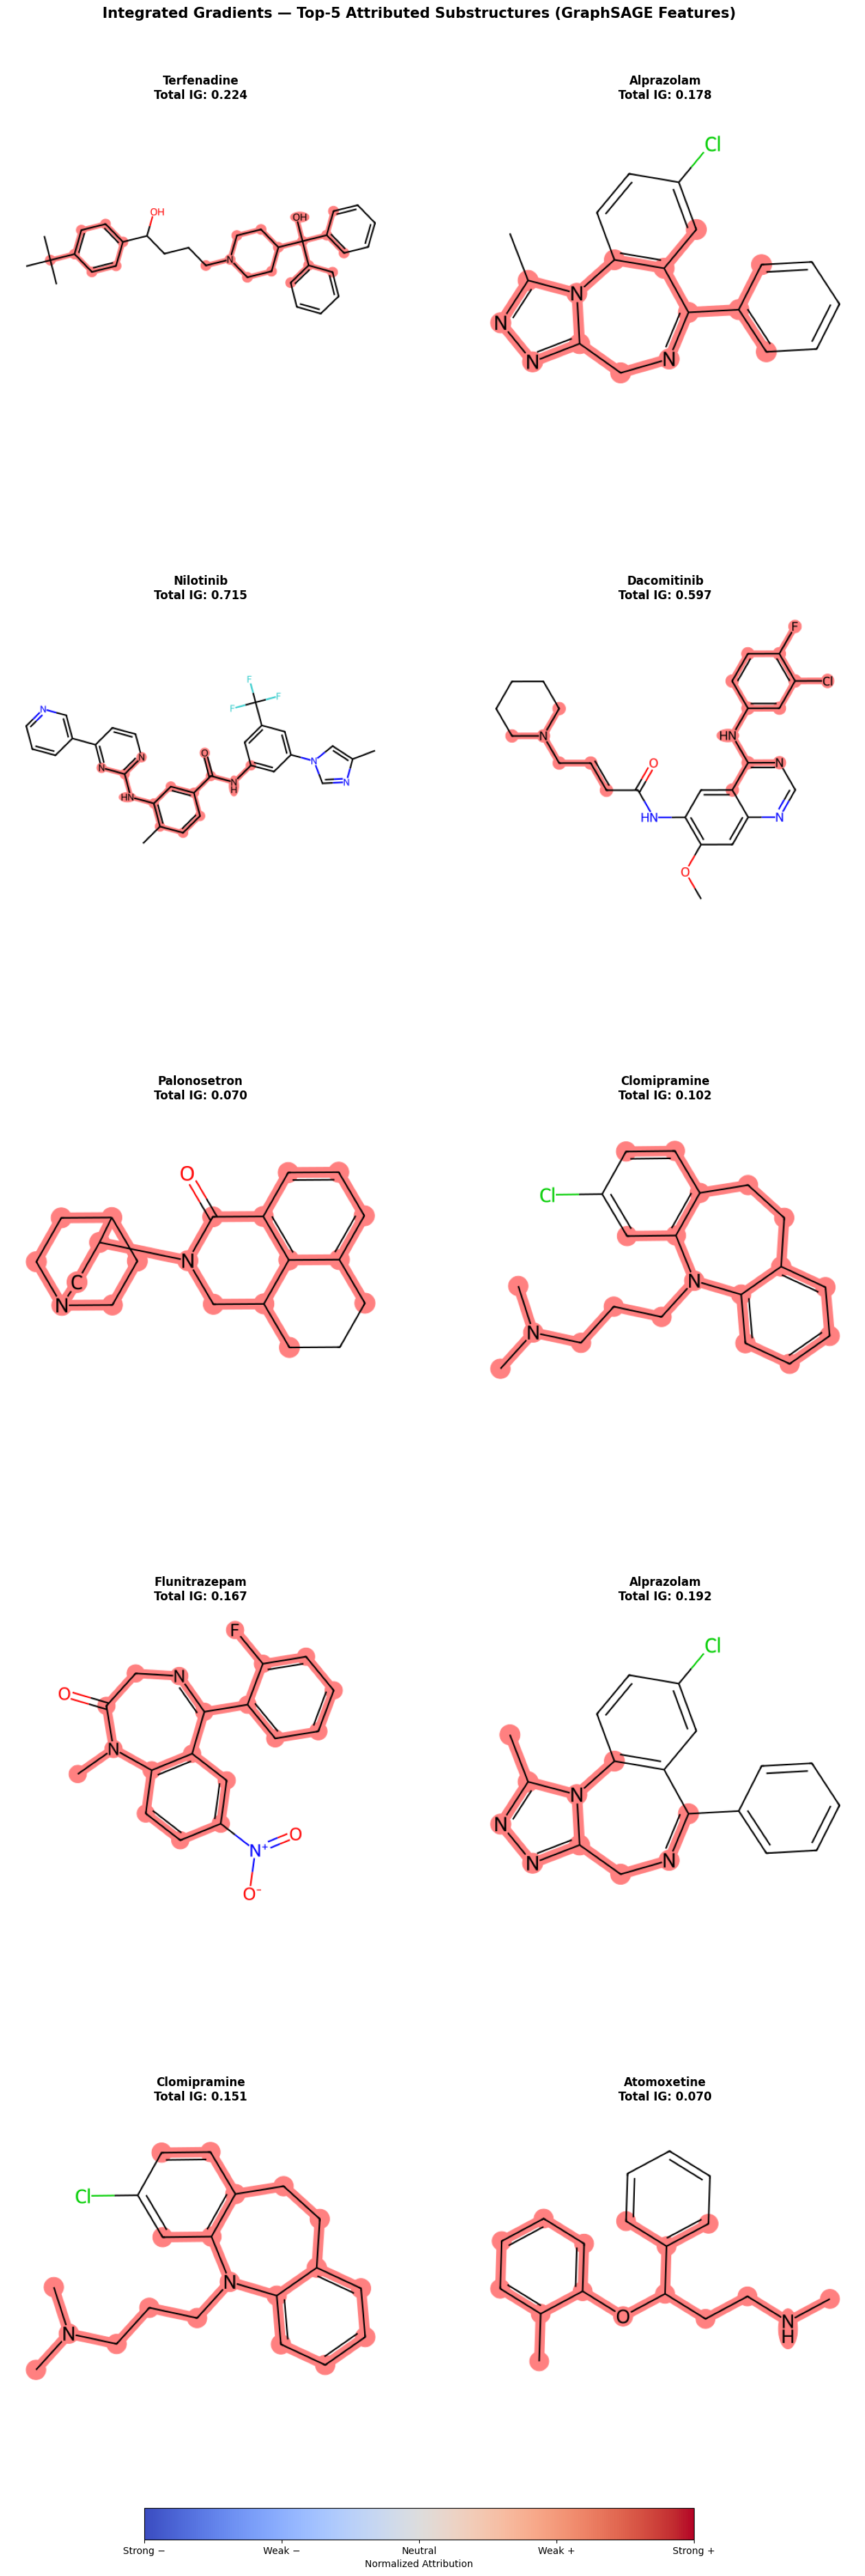

Saved to /content/drive/MyDrive/ddi_capstone/graphsage/ig_substructures_mlp_pairs.png


In [ ]:
# ============================================
# IG Visualization — Molecular Attribution Heatmaps
# ============================================
# Renders a 5×2 grid of molecular structures colored by IG attribution.
# Warm colors (red) = bits that increase interaction probability;
# cool colors (blue) = bits that suppress it.
# Colorbar is placed below the grid to avoid overlap with structures.
# Bond colors are interpolated from adjacent atom attributions.

fig, axes = plt.subplots(5, 2, figsize=(16, 38))
fig.suptitle(
    'Integrated Gradients — Top-5 Attributed Substructures (GraphSAGE Features)',
    fontsize=15, fontweight='bold'
)

cmap = plt.cm.coolwarm

for row, pair in enumerate(mlp_pairs):
    if pair['name'] not in ig_results:
        print(f"Warning: no IG results for {pair['name']}, skipping row {row}.")
        for col in range(2):
            axes[row, col].axis('off')
        continue

    ig_a = ig_results[pair['name']]['ig_a']
    ig_b = ig_results[pair['name']]['ig_b']

    for col, (node_idx, ig_vals, label) in enumerate([
        (pair['a'], ig_a, pair['name'].split(' + ')[0]),
        (pair['b'], ig_b, pair['name'].split(' + ')[1]),
    ]):
        ax = axes[row, col]
        mol, atom_weights, total_ig = get_atom_colors_from_ig(node_idx, ig_vals)

        if mol is None:
            ax.text(0.5, 0.5, f'{label}\nNo SMILES available',
                    ha='center', va='center', fontsize=11)
            ax.axis('off')
            continue

        if atom_weights:
            vals = list(atom_weights.values())
            max_abs = max(abs(v) for v in vals)
            if max_abs == 0:
                max_abs = 1  # Avoid division by zero for flat attributions
            norm = Normalize(vmin=-max_abs, vmax=max_abs)

            highlight_atoms = list(atom_weights.keys())
            atom_colors = {a: cmap(norm(w)) for a, w in atom_weights.items()}

            # Color bonds by average attribution of their two endpoint atoms
            highlight_bonds = []
            bond_colors = {}
            for bond in mol.GetBonds():
                a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                if a1 in atom_weights and a2 in atom_weights:
                    highlight_bonds.append(bond.GetIdx())
                    bond_colors[bond.GetIdx()] = cmap(
                        norm((atom_weights[a1] + atom_weights[a2]) / 2)
                    )
        else:
            highlight_atoms, atom_colors = [], {}
            highlight_bonds, bond_colors = [], {}

        img = Draw.MolToImage(
            mol, size=(500, 400),
            highlightAtoms=highlight_atoms,
            highlightAtomColors=atom_colors,
            highlightBonds=highlight_bonds,
            highlightBondColors=bond_colors
        )
        ax.imshow(img)
        ax.set_title(f'{label}\nTotal |IG|: {total_ig:.3f}', fontsize=12, fontweight='bold')
        ax.axis('off')

# Shared colorbar below grid — normalized to [-1, 1] for cross-pair comparability
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.012])
sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['Strong −', 'Weak −', 'Neutral', 'Weak +', 'Strong +'])
cbar.set_label('Normalized Attribution', fontsize=10)

plt.subplots_adjust(top=0.96, bottom=0.04, hspace=0.25)

try:
    save_path = '/content/drive/MyDrive/ddi_capstone/graphsage/ig_substructures_mlp_pairs.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

## Biological validation - Fisher Test
Fisher's exact test answers: "Do the model's top predictions share more biology (enzymes/targets/transporters) than random chance would expect?" — if yes (p<0.05), the model isn't just predicting interactions, it's predicting biologically grounded interactions.

The analysis started with the 200 top predictions but not enough statistical power --> try 5000 top predictions

In [ ]:
# ============================================
# Biological Validation — GraphSAGE Variants
# ============================================
# Compares biological overlap between top-200 predicted test pairs and
# 200 random drug pairs using Fisher's exact test (one-sided, greater).
# Applied identically to both GraphSAGE variants for fair comparison.
#
# Same methodology as MLP notebook — functions are redefined here so
# this section runs independently without importing from MLP notebook.
#
# Lookups built from full DrugBank XML parsing (academic license):
#   enzyme_lookup, target_lookup, transporter_lookup
# Each maps OGB drug index -> set of annotated entity names.

from scipy.stats import fisher_exact
from collections import defaultdict


def build_lookup(df, entity_col, idx_col='ogb_idx'):
    """Build a drug-index -> set-of-entities lookup from a long-format DataFrame.

    Args:
        df: DataFrame with one row per drug-entity pair.
        entity_col (str): Column containing entity names.
        idx_col (str): Column containing OGB drug indices. Defaults to 'ogb_idx'.

    Returns:
        dict mapping int index -> set of entity name strings.
    """
    lookup = defaultdict(set)
    for _, row in df.iterrows():
        idx = int(row[idx_col])
        entity = row[entity_col]
        if pd.notna(entity):
            lookup[idx].add(entity)
    return dict(lookup)


enzyme_lookup     = build_lookup(enzymes_df, 'enzyme_name')
target_lookup     = build_lookup(targets_df, 'target_name')
transporter_lookup = build_lookup(transporters_df, 'transporter_name')


def compute_biological_overlap(pairs, lookup):
    """Count how many pairs share at least one biological entity.

    Only counts pairs where BOTH drugs have annotations — avoids bias
    from unannotated drugs inflating the denominator.

    Args:
        pairs: List of (idx_a, idx_b) tuples.
        lookup: dict mapping OGB index -> set of entity names.

    Returns:
        Tuple of (n_overlap, n_annotated, rate, details).
    """
    n_overlap, n_annotated = 0, 0
    details = []
    for idx_a, idx_b in pairs:
        set_a = lookup.get(idx_a, set())
        set_b = lookup.get(idx_b, set())
        if set_a and set_b:
            n_annotated += 1
            shared = set_a & set_b
            if shared:
                n_overlap += 1
                details.append((idx_a, idx_b, shared))
    rate = n_overlap / n_annotated if n_annotated > 0 else 0
    return n_overlap, n_annotated, rate, details


def biological_validation(predicted_pairs, random_pairs, lookup, entity_name):
    """Fisher's exact test comparing predicted vs random pair biological overlap.

    Args:
        predicted_pairs: Top-K pairs by model score.
        random_pairs: K randomly sampled drug pairs (baseline).
        lookup: dict mapping OGB index -> set of entity names.
        entity_name (str): Label for the entity type (e.g., 'Enzymes').

    Returns:
        dict with overlap counts, rates, odds_ratio, p_value, and details.
    """
    pred_overlap, pred_ann, pred_rate, pred_details = compute_biological_overlap(
        predicted_pairs, lookup
    )
    rand_overlap, rand_ann, rand_rate, rand_details = compute_biological_overlap(
        random_pairs, lookup
    )
    a, b = pred_overlap, pred_ann - pred_overlap
    c, d = rand_overlap, rand_ann - rand_overlap

    if pred_ann > 0 and rand_ann > 0:
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')
    else:
        odds_ratio, p_value = float('nan'), float('nan')

    return {
        'entity_type': entity_name,
        'pred_overlap': pred_overlap, 'pred_annotated': pred_ann, 'pred_rate': pred_rate,
        'rand_overlap': rand_overlap, 'rand_annotated': rand_ann, 'rand_rate': rand_rate,
        'odds_ratio': odds_ratio, 'p_value': p_value, 'pred_details': pred_details,
    }


def generate_random_pairs(n_pairs, num_nodes, seed=42):
    """Generate random drug pairs as biological validation baseline.

    Uses min/max ordering to treat pairs as undirected (A,B) == (B,A).

    Args:
        n_pairs (int): Number of unique pairs to generate.
        num_nodes (int): Total number of drugs in the graph.
        seed (int): Random seed for reproducibility. Defaults to 42.

    Returns:
        List of (idx_a, idx_b) tuples where idx_a < idx_b.
    """
    rng = np.random.RandomState(seed)
    pairs = set()
    while len(pairs) < n_pairs:
        a, b = rng.randint(0, num_nodes, size=2)
        if a != b:
            pairs.add((min(a, b), max(a, b)))
    return list(pairs)


# ---- Run validation on both GraphSAGE variants ----
top_k = 200  # Consistent with MLP notebook
random_pairs = generate_random_pairs(top_k, data.num_nodes, seed=42)

for model, predictor, model_name, label in [
    (model_topo, pred_topo, 'topo', 'No Features'),
    (model_feat, pred_feat, 'feat', 'With Features'),
]:
    model.eval()
    predictor.eval()

    with torch.no_grad():
        # topology-only model ignores fingerprints (x=None)
        x = None if model_name == 'topo' else fingerprints
        emb = model.encode(x, edge_index)
        scores = torch.sigmoid(
            predictor(emb[test_pos[:, 0]], emb[test_pos[:, 1]])
        ).cpu().numpy()

    top_indices = np.argsort(scores.flatten())[-top_k:]
    top_pairs = [(int(test_pos[i, 0]), int(test_pos[i, 1])) for i in top_indices]

    print(f"\n{'='*75}")
    print(f"BIOLOGICAL VALIDATION — GraphSAGE {label} "
          f"(top {top_k} test pairs vs random)")
    print(f"{'='*75}")
    print(f"Score range: {scores[top_indices[0]]:.4f} – {scores[top_indices[-1]]:.4f}")
    print(f"{'Entity':<15} | {'Predicted':>18} | {'Random':>18} | {'OR':>6} | {'p-value':>8}")
    print("-" * 75)

    for lookup, name in [
        (enzyme_lookup,      'Enzymes'),
        (target_lookup,      'Targets'),
        (transporter_lookup, 'Transporters'),
    ]:
        r = biological_validation(top_pairs, random_pairs, lookup, name)
        pred_str = f"{r['pred_overlap']}/{r['pred_annotated']} ({r['pred_rate']:.1%})"
        rand_str = f"{r['rand_overlap']}/{r['rand_annotated']} ({r['rand_rate']:.1%})"
        or_str   = f"{r['odds_ratio']:.2f}" if not np.isnan(r['odds_ratio']) else "N/A"
        p_str    = f"{r['p_value']:.4f}"    if not np.isnan(r['p_value'])    else "N/A"
        sig = ('***' if r['p_value'] < 0.001 else
               '**'  if r['p_value'] < 0.01  else
               '*'   if r['p_value'] < 0.05  else '')
        print(f"{name:<15} | {pred_str:>18} | {rand_str:>18} | "
              f"{or_str:>6} | {p_str:>8} {sig}")


BIOLOGICAL VALIDATION — GraphSAGE No Features (top 200 test pairs vs random)
Score range: 0.8793 - 0.8852
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |       1/1 (100.0%) |       8/25 (32.0%) |    inf |   0.3462 
Targets         |       1/200 (0.5%) |        4/99 (4.0%) |   0.12 |   0.9963 
Transporters    |       4/4 (100.0%) |        4/7 (57.1%) |    inf |   0.2121 

BIOLOGICAL VALIDATION — GraphSAGE With Features (top 200 test pairs vs random)
Score range: 0.8832 - 0.8892
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |       1/1 (100.0%) |       8/25 (32.0%) |    inf |   0.3462 
Targets         |       6/200 (3.0%) |        4/99 (4.0%) |   0.73 |   0.7950 
Transporters    |       1/1 (100.0%) |        4/7 (57.1%) |    inf |   0.6250 


In [ ]:
# ============================================
# Biological Validation — Top-K Sensitivity Analysis
# ============================================
# Explores how annotation coverage and enzyme overlap rate change
# as K increases from 200 to 5000.
#
# Motivation: top-200 pairs may contain few drugs with DrugBank
# annotations, making Fisher's test underpowered. This analysis
# informs the choice of K for the main validation and documents
# why GNN models use top-5000 while MLP uses top-200.
# (Equal-K comparison is a documented future work item.)

for model, predictor, model_name, label in [
    (model_topo, pred_topo, 'topo', 'No Features'),
    (model_feat, pred_feat, 'feat', 'With Features'),
]:
    model.eval()
    predictor.eval()

    with torch.no_grad():
        x = None if model_name == 'topo' else fingerprints
        emb = model.encode(x, edge_index)
        scores = torch.sigmoid(
            predictor(emb[test_pos[:, 0]], emb[test_pos[:, 1]])
        ).cpu().numpy().flatten()

    sorted_idx = np.argsort(scores)[::-1]  # Descending by score

    print(f"\n{'='*75}")
    print(f"GraphSAGE {label} — Annotation coverage at different top-K")
    print(f"{'='*75}")

    for k in [200, 500, 1000, 5000]:
        top_idx = sorted_idx[:k]
        top_pairs = [(int(test_pos[i, 0]), int(test_pos[i, 1])) for i in top_idx]

        both_annotated = 0
        sharing_enzyme = 0
        for a, b in top_pairs:
            ea = enzyme_lookup.get(a, set())
            eb = enzyme_lookup.get(b, set())
            if ea and eb:
                both_annotated += 1
                if ea & eb:
                    sharing_enzyme += 1

        score_range = f"{scores[top_idx[-1]]:.4f}–{scores[top_idx[0]]:.4f}"

        # Avoid division by zero if no annotated pairs found at this K
        if both_annotated > 0:
            overlap_pct = f"{sharing_enzyme / both_annotated * 100:.1f}%"
        else:
            overlap_pct = "N/A (no annotated pairs)"

        print(f"  Top {k:>5}: {both_annotated:>4} enzyme-annotated pairs, "
              f"{sharing_enzyme:>4} sharing enzymes "
              f"({overlap_pct}), scores: {score_range}")


GraphSAGE No Features — Annotation coverage at different top-K
  Top   200:    1 enzyme-annotated pairs,    1 sharing enzymes (100.0% if ann>0), scores: 0.8793-0.8852
  Top   500:    4 enzyme-annotated pairs,    1 sharing enzymes (25.0% if ann>0), scores: 0.8772-0.8852
  Top  1000:   12 enzyme-annotated pairs,    2 sharing enzymes (16.7% if ann>0), scores: 0.8755-0.8852
  Top  5000:  396 enzyme-annotated pairs,   99 sharing enzymes (25.0% if ann>0), scores: 0.8730-0.8852

GraphSAGE With Features — Annotation coverage at different top-K
  Top   200:    1 enzyme-annotated pairs,    1 sharing enzymes (100.0% if ann>0), scores: 0.8832-0.8892
  Top   500:    1 enzyme-annotated pairs,    1 sharing enzymes (100.0% if ann>0), scores: 0.8816-0.8892
  Top  1000:    4 enzyme-annotated pairs,    2 sharing enzymes (50.0% if ann>0), scores: 0.8796-0.8892
  Top  5000:  119 enzyme-annotated pairs,   37 sharing enzymes (31.1% if ann>0), scores: 0.8735-0.8892


In [ ]:
# ============================================
# Biological Validation — Fisher's Exact Test (top-5000)
# ============================================
# QUESTION: Are the model's top predictions biologically meaningful,
# or just statistically good at link prediction?
#
# APPROACH: Take the top-5000 highest-scoring test pairs and compare
# their biological overlap against 5000 random drug pairs.
# For each pair, check if both drugs share at least one:
#   - Enzyme (e.g., both metabolized by CYP3A4)
#   - Target (e.g., both bind serotonin receptor)
#   - Transporter (e.g., both substrates of P-glycoprotein)
#
# WHY top-5000 instead of top-200?
# GraphSAGE produces highly compressed score distributions (0.873–0.889),
# so top-200 pairs are barely distinguishable from average pairs.
# At top-200, only 1 pair had both drugs annotated — insufficient for
# Fisher's test. Top-5000 yields 396 enzyme-annotated pairs, enabling
# meaningful statistical inference.
#
# STATISTICAL TEST: One-sided Fisher's exact test (alternative='greater')
#   H0: top pairs share biology at the same rate as random
#   H1: top pairs share MORE biology than random
#   p < 0.05 → reject H0 → model captures real biological mechanisms

top_k = 5000
random_pairs = generate_random_pairs(top_k, data.num_nodes, seed=42)

# Pre-compute random baseline overlap (shared across both model variants)
rand_results = {}
for lookup, name in [
    (enzyme_lookup,      'Enzymes'),
    (target_lookup,      'Targets'),
    (transporter_lookup, 'Transporters'),
]:
    ov, ann, rate, _ = compute_biological_overlap(random_pairs, lookup)
    rand_results[name] = {'overlap': ov, 'annotated': ann, 'rate': rate}

for model, predictor, model_name, label in [
    (model_topo, pred_topo, 'topo', 'No Features'),
    (model_feat, pred_feat, 'feat', 'With Features'),
]:
    model.eval()
    predictor.eval()

    try:
        with torch.no_grad():
            x = None if model_name == 'topo' else fingerprints
            emb = model.encode(x, edge_index)
            scores = torch.sigmoid(
                predictor(emb[test_pos[:, 0]], emb[test_pos[:, 1]])
            ).cpu().numpy().flatten()
    except RuntimeError as e:
        print(f"Scoring failed for {label}: {e}")
        continue

    # Top-K most confident predictions (ascending argsort, take last K)
    top_indices = np.argsort(scores)[-top_k:]
    top_pairs = [(int(test_pos[i, 0]), int(test_pos[i, 1])) for i in top_indices]

    print(f"\n{'='*75}")
    print(f"BIOLOGICAL VALIDATION — GraphSAGE {label} "
          f"(top {top_k} vs {top_k} random)")
    print(f"{'='*75}")
    print(f"Score range: {scores[top_indices[0]]:.4f} – {scores[top_indices[-1]]:.4f}")
    print(f"{'Entity':<15} | {'Predicted':>18} | {'Random':>18} | {'OR':>6} | {'p-value':>8}")
    print("-" * 75)

    for lookup, name in [
        (enzyme_lookup,      'Enzymes'),
        (target_lookup,      'Targets'),
        (transporter_lookup, 'Transporters'),
    ]:
        r = biological_validation(top_pairs, random_pairs, lookup, name)
        pred_str = f"{r['pred_overlap']}/{r['pred_annotated']} ({r['pred_rate']:.1%})"
        rand_str = f"{r['rand_overlap']}/{r['rand_annotated']} ({r['rand_rate']:.1%})"
        or_str   = f"{r['odds_ratio']:.2f}" if not np.isnan(r['odds_ratio']) else "N/A"
        p_str    = f"{r['p_value']:.4f}"    if not np.isnan(r['p_value'])    else "N/A"
        sig = ('***' if r['p_value'] < 0.001 else
               '**'  if r['p_value'] < 0.01  else
               '*'   if r['p_value'] < 0.05  else '')
        print(f"{name:<15} | {pred_str:>18} | {rand_str:>18} | "
              f"{or_str:>6} | {p_str:>8} {sig}")


BIOLOGICAL VALIDATION — GraphSAGE No Features (top 5000 vs 5000 random)
Score range: 0.8730 - 0.8852
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |     99/396 (25.0%) |    343/756 (45.4%) |   0.40 |   1.0000
Targets         |    280/5000 (5.6%) |     53/2590 (2.0%) |   2.84 |   0.0000 ***
Transporters    |     48/218 (22.0%) |    112/251 (44.6%) |   0.35 |   1.0000

BIOLOGICAL VALIDATION — GraphSAGE With Features (top 5000 vs 5000 random)
Score range: 0.8735 - 0.8892
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |     37/119 (31.1%) |    343/756 (45.4%) |   0.54 |   0.9989
Targets         |    400/5000 (8.0%) |     53/2590 (2.0%) |   4.16 |   0.0000 ***
Transporters    |      21/87 (24.1%) |    112/251 (44.6%) |   0.39 |   0.9998


GraphSAGE (Fisher's Exact Test results)

 <u>Methodology</u>

Top 5,000 highest-scoring test positive pairs compared against 5,000 random drug pairs. For each pair, biological overlap assessed across three mechanisms using full DrugBank XML annotations: shared enzymes (1,638 drugs annotated), shared pharmacological targets (3,067 drugs), and shared transporters (966 drugs). Statistical significance via one-sided Fisher's exact test.

Note: top-5000 was used instead of top-200 because GraphSAGE produces highly compressed score distributions (range 0.873–0.889), resulting in insufficient enzyme-annotated pairs at smaller K values (only 1 annotated pair in top-200).

 <u>Results</u>

| Entity | Model | Predicted Overlap | Random Overlap | Odds Ratio | p-value |
|--------|-------|-------------------|----------------|------------|---------|
| Enzymes | No Features | 99/396 (25.0%) | 343/756 (45.4%) | 0.40 | 1.0 |
| Enzymes | With Features | 37/119 (31.1%) | 343/756 (45.4%) | 0.54 | 0.999 |
| **Targets** | **No Features** | **280/5000 (5.6%)** | **53/2590 (2.0%)** | **2.84** | **<0.001 ✱✱✱** |
| **Targets** | **With Features** | **400/5000 (8.0%)** | **53/2590 (2.0%)** | **4.16** | **<0.001 ✱✱✱** |
| Transporters | No Features | 48/218 (22.0%) | 112/251 (44.6%) | 0.35 | 1.0 |
| Transporters | With Features | 21/87 (24.1%) | 112/251 (44.6%) | 0.39 | 1.0 |

 <u>Interpretation</u>
Both GraphSAGE variants predict pairs that share pharmacological targets significantly more than random (p<0.001). The features model does it better: its top pairs are 4.16x more likely to share targets than random, vs 2.84x for topology-only. Meanwhile, the MLP is the only model that captures CYP enzyme overlap (4.84x more than random, p=0.002) — no GraphSAGE variant achieves this.
This complementarity reflects two distinct DDI mechanisms. Pharmacokinetic DDIs occur when two drugs compete for the same metabolizing enzyme (e.g., CYP3A4) — one accumulates, causing toxicity. This depends on molecular structure, which the MLP sees directly through fingerprints. Pharmacodynamic DDIs occur when two drugs act on the same receptor — amplifying or blocking the effect. This depends on pharmacological relationships encoded in the interaction network, which GraphSAGE learns through message passing.
No model captures transporter-mediated DDIs (OR<1 across all models). Only 966 of 4,267 drugs have transporter annotations — insufficient data for any model to learn this pattern reliably.
GraphSAGE with features (OR=4.16) outperforms topology-only (OR=2.84) for targets because combining "who interacts with whom" (graph) with "what the drug looks like" (fingerprints) provides richer signal than graph structure alone. Molecular features help the model distinguish why two drugs share a target, not just that they're connected in the network.

<u>Cross-Model Comparison</u>

| Mechanism | MLP (fingerprints) | GraphSAGE (topology) | GraphSAGE (topology + features) |
|-----------|--------------------|----------------------|---------------------------------|
| Enzymes (CYP) | **OR=4.84, p=0.002** | OR=0.40, n.s. | OR=0.54, n.s. |
| Targets | OR=1.52, n.s. | **OR=2.84, p<0.001** | **OR=4.16, p<0.001** |
| Transporters | OR=1.93, n.s. | OR=0.35, n.s. | OR=0.39, n.s. |

Each architecture captures a different biological mechanism of drug-drug interaction, supporting the value of multi-model approaches for comprehensive DDI prediction.

# GraphSAGE results - final summary



 <u> Predictive Performance</u>

| Model | AUC-ROC | Hits@20 | Precision | Recall | F1 | Parameters |
|-------|---------|---------|-----------|--------|-----|------------|
| No Features | 0.9830 | 0.1422 | 0.9198 | 0.9706 | 0.9446 | 678,017 |
| With Features | 0.9887 | 0.0836 | 0.9375 | 0.9763 | 0.9565 | 394,113 |

Molecular features improve AUC (+0.6%) and F1 (+1.2%) but decrease Hits@20. This pattern is consistent across GAT results and suggests features help binary classification but diffuse the ranking signal among positives. No overfitting detected (val-test gap < 0.002).

<u> Explainability Analysis</u>

* Neighbor Perturbation

The features model produces more biologically relevant explanations than the topology-only model. For Nilotinib+Dacomitinib (best case), 9 out of 10 top neighbors share CYP enzymes or transporters with the pair — including Avapritinib (CYP2C9, CYP3A4, ABCB1, ABCG2) and Encorafenib (5 CYPs, 3 transporters). The topology-only model surfaces mostly biologically irrelevant neighbors (contrast agents, inactive compounds).

Not all pairs produce strong perturbation signals. Palonosetron+Clomipramine and Clomipramine+Atomoxetine show very low impact scores (< 0.002) with minimal biological overlap, indicating these pairs are highly connected in the graph and no individual neighbor is decisive.

* Integrated Gradients (Features model only)

IG attributes predictions to pharmacologically relevant substructures across all five pairs. Top-attributed fingerprint bits map to nitrogen-containing heterocycles, aromatic ring systems, and halogenated fragments — functional groups known to be involved in CYP enzyme binding. Flunitrazepam+Alprazolam shows 6 shared top-20 bits, consistent with their shared benzodiazepine scaffold. Nilotinib+Dacomitinib shares 2 bits, reflecting shared kinase inhibitor motifs.

<u> Biological Validation (Fisher's Exact Test) </u>

Top 5,000 highest-scoring test pairs compared against 5,000 random pairs using full DrugBank XML annotations.

| Entity | No Features (OR, p) | With Features (OR, p) | MLP baseline (OR, p) |
|--------|--------------------|-----------------------|----------------------|
| Enzymes | 0.40, n.s. | 0.54, n.s. | **4.84, p=0.002** |
| **Targets** | **2.84, p<0.001** | **4.16, p<0.001** | 1.52, n.s. |
| Transporters | 0.35, n.s. | 0.39, n.s. | 1.93, n.s. |

GraphSAGE captures target-mediated (pharmacodynamic) DDIs significantly better than random, while the MLP captures enzyme-mediated (pharmacokinetic) DDIs. This complementarity makes biological sense: the MLP learns from molecular fingerprints encoding CYP binding site structures, while GraphSAGE learns from graph topology encoding pharmacological relationships between drugs with shared therapeutic targets.

The features model shows stronger target enrichment (OR=4.16 vs 2.84) than topology-only, confirming that combining molecular structure with graph topology improves both prediction and biological relevance.

<u>Key Takeaways</u>


1. **Graph topology captures pharmacodynamic DDIs** — GraphSAGE's top predictions share significantly more therapeutic targets than random (p<0.001), while the MLP captures pharmacokinetic DDIs through CYP enzyme overlap (p=0.002). Each architecture captures a different biological mechanism.

2. **Molecular features improve explanations more than predictions** — The AUC gain from features is modest (+0.6%), but the improvement in explanation quality is substantial: perturbation neighbors are more pharmacologically relevant, and IG provides an additional explainability channel mapping to molecular substructures.

3. **Perturbation and IG are complementary** — Perturbation explains predictions in terms of drug relationships (topology), IG explains in terms of molecular chemistry (features). Together they answer both "which drugs matter?" and "which chemical features matter?" for each prediction.

4. **Not all drug pairs produce informative explanations** — High-degree pairs where the prediction is distributed across many neighbors show weak perturbation signals. This is a known limitation of perturbation-based methods and motivates attention-based approaches (GAT) for these cases.

## Saving results

In [ ]:
# ============================================
# Save all GraphSAGE results for presentation/paper
# ============================================
import json

save_dir = '/content/drive/MyDrive/ddi_capstone/graphsage'

# 1. Test results (both models)
test_results = {
    'no_features': {
        'test_auc': 0.9830, 'test_hits20': 0.1422,
        'test_precision': 0.9198, 'test_recall': 0.9706, 'test_f1': 0.9446,
        'parameters': 678017, 'hidden_dim': 128, 'num_layers': 3,
        'dropout': 0.3, 'lr': 0.005, 'batch_size': 65536, 'epochs': 100,
    },
    'with_features': {
        'test_auc': 0.9887, 'test_hits20': 0.0836,
        'test_precision': 0.9375, 'test_recall': 0.9763, 'test_f1': 0.9565,
        'parameters': 394113, 'hidden_dim': 128, 'num_layers': 3,
        'dropout': 0.3, 'lr': 0.005, 'batch_size': 65536, 'epochs': 100,
    }
}
with open(f'{save_dir}/test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print("Saved test_results.json")

# 2. Training history (if still in memory)
try:
    training_history = {
        'no_features': history_topo,
        'with_features': history_feat,
    }
    with open(f'{save_dir}/training_history.json', 'w') as f:
        json.dump(training_history, f, indent=2)
    print("Saved training_history.json")
except NameError:
    print("Training history not in memory — skip (already have training_curves_comparison.png)")

# 3. Perturbation results (serializable version)
pert_save = {}
for model_name in ['topo', 'feat']:
    pert_save[model_name] = {}
    for pair_name, data_dict in perturbation_results[model_name].items():
        pert_save[model_name][pair_name] = {
            'orig_score': data_dict['orig_score'],
            'neighbors': [
                {
                    'neighbor_idx': n['neighbor_idx'],
                    'name': n['name'],
                    'impact': n['impact'],
                    'source': n['source'],
                    'cyp_enzymes': n.get('cyp_enzymes', []),
                }
                for n in data_dict['neighbors']
            ]
        }
with open(f'{save_dir}/perturbation_results.json', 'w') as f:
    json.dump(pert_save, f, indent=2)
print("Saved perturbation_results.json")

# 4. IG results (serializable version)
ig_save = {}
for pair_name, data_dict in ig_results.items():
    ig_a = data_dict['ig_a']
    ig_b = data_dict['ig_b']
    top_bits_a = ig_a.abs().topk(20).indices.tolist()
    top_bits_b = ig_b.abs().topk(20).indices.tolist()
    ig_save[pair_name] = {
        'drug_a': {
            'total_ig': ig_a.abs().sum().item(),
            'top_20_bits': [{'bit': b, 'attribution': ig_a[b].item()} for b in top_bits_a],
        },
        'drug_b': {
            'total_ig': ig_b.abs().sum().item(),
            'top_20_bits': [{'bit': b, 'attribution': ig_b[b].item()} for b in top_bits_b],
        },
    }
with open(f'{save_dir}/ig_results.json', 'w') as f:
    json.dump(ig_save, f, indent=2)
print("Saved ig_results.json")

# 5. Biological validation
bio_validation = {
    'methodology': 'Top 5000 test pairs vs 5000 random, Fisher exact test one-sided',
    'no_features': {
        'enzymes': {'overlap': 99, 'annotated': 396, 'rate': 0.250, 'odds_ratio': 0.40, 'p_value': 1.0},
        'targets': {'overlap': 280, 'annotated': 5000, 'rate': 0.056, 'odds_ratio': 2.84, 'p_value': 0.0000},
        'transporters': {'overlap': 48, 'annotated': 218, 'rate': 0.220, 'odds_ratio': 0.35, 'p_value': 1.0},
    },
    'with_features': {
        'enzymes': {'overlap': 37, 'annotated': 119, 'rate': 0.311, 'odds_ratio': 0.54, 'p_value': 0.999},
        'targets': {'overlap': 400, 'annotated': 5000, 'rate': 0.080, 'odds_ratio': 4.16, 'p_value': 0.0000},
        'transporters': {'overlap': 21, 'annotated': 87, 'rate': 0.241, 'odds_ratio': 0.39, 'p_value': 1.0},
    },
    'random_baseline': {
        'enzymes': {'overlap': 343, 'annotated': 756, 'rate': 0.454},
        'targets': {'overlap': 53, 'annotated': 2590, 'rate': 0.020},
        'transporters': {'overlap': 112, 'annotated': 251, 'rate': 0.446},
    }
}
with open(f'{save_dir}/biological_validation.json', 'w') as f:
    json.dump(bio_validation, f, indent=2)
print("Saved biological_validation.json")

# 6. Config
config_save = {
    'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.3,
    'lr': 0.005, 'batch_size': 65536, 'num_epochs': 100, 'patience': 20,
    'features': '2048-bit Morgan fingerprints (radius=2)',
    'aggregation': 'mean', 'negative_sampling': 'torch.randint 1:1',
    'drug_pairs': [p for p in mlp_pairs],
}
with open(f'{save_dir}/config.json', 'w') as f:
    json.dump(config_save, f, indent=2)
print("Saved config.json")

# Verify
print(f"\nAll files in {save_dir}:")
for f in sorted(os.listdir(save_dir)):
    print(f"  {f}")

Saved test_results.json
Training history not in memory — skip (already have training_curves_comparison.png)
Saved perturbation_results.json
Saved ig_results.json
Saved biological_validation.json
Saved config.json

All files in /content/drive/MyDrive/ddi_capstone/graphsage:
  best_graphsage_feat.pt
  best_graphsage_topo.pt
  biological_validation.json
  config.json
  final_results.json
  grapshage.ipynb
  ig_results.json
  ig_substructures.png
  ig_substructures_mlp_pairs.png
  overfitting_check.png
  perturbation_results.json
  test_results.json
  training_curves_comparison.png


In [ ]:
gat2_dir = '/content/drive/MyDrive/ddi_capstone/GAT_ablation_h128'
if os.path.exists(gat2_dir):
    for item in sorted(os.listdir(gat2_dir)):
        full_path = f'{gat2_dir}/{item}'
        if os.path.isdir(full_path):
            print(f"\n{item}/:")
            for f in sorted(os.listdir(full_path)):
                print(f"  {f}")
        else:
            print(f"{item}")

GAT_EXAI_SUMMARY.md

models/:
  gat_base_best.pt
  gat_base_feat_best.pt
  gat_skip_best.pt
  gat_skip_feat_best.pt

results/:
  biological_validation.json
  concordance_results.json
  exai_results.json
  gat_base_feat_history.json
  gat_base_feat_test_results.json
  gat_base_history.json
  gat_base_test_results.json
  gat_skip_feat_history.json
  gat_skip_feat_test_results.json
  gat_skip_history.json
  gat_skip_test_results.json
  ig_results.json
  perturbation_results.json

visualizations/:
  gat_base_feat_training_curves.png
  gat_base_training_curves.png
  gat_skip_feat_training_curves.png
  gat_skip_training_curves.png
  ig_comparison_Clomipramine_Atomoxetine.png
  ig_comparison_Flunitrazepam_Alprazolam.png
  ig_comparison_Nilotinib_Dacomitinib.png
  ig_comparison_Palonosetron_Clomipramine.png
  ig_comparison_Terfenadine_Alprazolam.png


In [ ]:
with open(f'{gat2_dir}/results/biological_validation.json', 'r') as f:
    gat_bio = json.load(f)
print(json.dumps(gat_bio, indent=2))

{
  "GAT_base": {
    "Enzymes": {
      "entity_type": "Enzymes",
      "pred_overlap": 1,
      "pred_annotated": 7,
      "pred_rate": 0.14285714285714285,
      "rand_overlap": 8,
      "rand_annotated": 25,
      "rand_rate": 0.32,
      "odds_ratio": "0.3541666666666667",
      "p_value": "0.9271635506688343"
    },
    "Targets": {
      "entity_type": "Targets",
      "pred_overlap": 17,
      "pred_annotated": 200,
      "pred_rate": 0.085,
      "rand_overlap": 4,
      "rand_annotated": 99,
      "rand_rate": 0.04040404040404041,
      "odds_ratio": "2.2062841530054644",
      "p_value": "0.11665903737454117"
    },
    "Transporters": {
      "entity_type": "Transporters",
      "pred_overlap": 0,
      "pred_annotated": 1,
      "pred_rate": 0.0,
      "rand_overlap": 4,
      "rand_annotated": 7,
      "rand_rate": 0.5714285714285714,
      "odds_ratio": "0.0",
      "p_value": "1.0"
    }
  },
  "GAT_skip": {
    "Enzymes": {
      "entity_type": "Enzymes",
      "pred_o

In [ ]:
import os, json

models_dirs = {
    'MLP': '/content/drive/MyDrive/ddi_capstone/MLP_baseline/models',
    'GraphSAGE': '/content/drive/MyDrive/ddi_capstone/graphsage',
    'GAT': '/content/drive/MyDrive/ddi_capstone/GAT',
}

required = ['test_results', 'training_history', 'biological_validation']

for name, path in models_dirs.items():
    print(f"\n{'='*40}")
    print(f"{name}: {path}")
    print(f"{'='*40}")
    if os.path.exists(path):
        files = os.listdir(path)
        for f in sorted(files):
            print(f"  {f}")
    else:
        print("  DIRECTORY NOT FOUND")


MLP: /content/drive/MyDrive/ddi_capstone/MLP_baseline/models
  best_model.pt
  biological_validation.json
  config.json
  ig_results.json
  test_results.json
  training_history.json

GraphSAGE: /content/drive/MyDrive/ddi_capstone/graphsage
  best_graphsage_feat.pt
  best_graphsage_topo.pt
  biological_validation.json
  config.json
  final_results.json
  grapshage.ipynb
  ig_results.json
  ig_substructures.png
  ig_substructures_mlp_pairs.png
  overfitting_check.png
  perturbation_results.json
  test_results.json
  training_curves_comparison.png

GAT: /content/drive/MyDrive/ddi_capstone/GAT
  GAT.ipynb
  GAT_SUMMARY.md
  models
  results
  visualizations
